# Is openness before take-off brokerage or churn? (RQ1 deepen, iteration 3)

This notebook is a runnable demo of experiment **art_htO_gJuUn6Pr**, which studies emerging scientific concepts in a yearly co-word network built from OpenAlex.

**The question.** In iteration 2, concepts that later took off (label **E_up**, sustained uptake: at least 20 papers a year on average over t+1..t+5, with no fall of more than 30%) had **lower neighbourhood closure** in the years before onset. Their top-20 co-word neighbours were less tied to each other than a Chung-Lu null predicts. There are two readings:

* **BROKERAGE**: the concept sits between otherwise unconnected neighbours, as in Burt's structural holes.
* **TURNOVER (churn)**: the neighbourhood keeps changing, so the top-20 set is just a sample of loosely related terms.

**What the original `method.py` does.** It is an orchestrator. It runs 19 pipeline steps (`src/*.py`) as subprocesses over OpenAlex snapshots that are several GB in size:

| step | module | what it does |
|---|---|---|
| 0-2 | `setup`, `population`, `prep3` | vendor the iteration-2 code byte-identical, write the pre-registration, build the MAIN / STRICT / SENS populations |
| 3-4 | `attach`, `indicators3`, `repro` | re-attach concepts to the co-word snapshots and compute the per-(concept, year) indicators, including the new **turnover-proof openness measures** R1a / R1b / R1c; run the reproduction gate |
| 5 | `labels3`, `leakage` | E_up / E_alt / E labels on the screen fold only; leakage test |
| **6** | **`event3`** | **matched event study (S over k = -3..0), Holm family, sensitivities, pooled panels, R1a correlations, R1d** |
| **7** | **`verdict`** | **mechanical BROKERAGE / TURNOVER / MIXED verdict** |
| 8 | `power` | held-out minimum detectable effect (MDE) |
| **9** | **`predict3`** | **grouped-CV delta-AUC (reported, not claimed)** |
| 10 | `figs`, `audit`, `exports`, `freeze` | figures, independent audit, exports, hash freeze |

**What this notebook runs.** Steps 3-5 need the multi-GB snapshots, so they cannot run here. Their output for 100 concepts (the per-concept-year indicator panel plus the labels) is shipped in `mini_demo_data.json`. The notebook then runs the analysis modules on that data, with the original code copied verbatim and split into cells:
* the R1c Burt metrics (`openness.py`) and their check against networkx;
* the R1a turnover residualisation (`indicators3.py`);
* the full step 6 event study (`event3.py`, using the vendored `analysis_event.py`);
* the step 7 verdict (`verdict.py`);
* the step 9 prediction (`predict3.py`, using the vendored `analysis_predict.py`).

The 100 concepts include every concept used by the primary matched cell. That cell's S and CIs therefore **reproduce the full run exactly** once the bootstrap count is set to the original B = 2000. The pooled panels, placebo, grid and prediction run on the 100-concept subset, so their numbers differ from the full run of 202 MAIN concepts.

Full-run headline: raw closure S = -0.439 [-0.810, -0.050]; R1a S = -0.295 [-0.663, 0.092]; R1b S = -0.575 [-1.270, 0.122]; constraint S = +0.083 [0.017, 0.147]. **Verdict: MIXED.**

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, statsmodels, matplotlib, networkx — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'statsmodels==0.14.6',
         'matplotlib==3.10.0', 'networkx==3.6.1')

In [2]:
# --- original method.py import block ---
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")

import argparse  # noqa: E402
import subprocess  # noqa: E402
import sys  # noqa: E402
import time  # noqa: E402
from pathlib import Path  # noqa: E402

from loguru import logger  # noqa: E402

# --- imports of the src/ and vendor/ modules that are run below ---
import hashlib
import json
import math
import warnings
from collections.abc import Iterable, Sequence
from types import SimpleNamespace

import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# --- notebook-only: visualisation and the networkx reference for the Burt metrics ---
import matplotlib.pyplot as plt
import networkx as nx

logger.remove()
_ = logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-3/experiment-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("concepts:", data["metadata"]["n_concepts"], "| indicator rows:", data["metadata"]["n_indicator_rows"],
      "| label rows:", data["metadata"]["n_label_rows"])

100 MAIN screen-fold concepts of the hydrated OpenAlex co-word pool: per-concept emergence labels (E_up = sustained uptake, onset years 2008-2015) and per-(concept, year) network indicators (raw closure, R1a turnover-residualised closure, R1b persistent-neighbour closure, R1c Burt constraint / effective size, cross-community pair excess, within-module z, turnover covariates).
concepts: 100 | indicator rows: 1842 | label rows: 438


## Configuration

These are all the tunable parameters. On the 100-concept demo data the **original pipeline values** (given in the comments) run in about 2 minutes, so they are used as-is. For a quicker smoke test, set every bootstrap to 50, `PRED_SEEDS = [0]`, `PRED_SHUFFLES = 2`, `N_EGO_TEST_GRAPHS = 5` and `GRID_LABELS = ("E_up",)`. That runs in about 15 s. The point estimates S do not depend on B. The primary-cell CIs reproduce the full run exactly only at B_BOOT = 2000.

In [5]:
# Bootstrap replicates for the primary matched event study and its sensitivities (original SPEC3["bootstrap"] = 2000)
B_BOOT = 2000
# Bootstrap replicates for the non-primary grid cells (original SPEC3["bootstrap_nonprimary"] = 2000)
B_NONPRIMARY = 2000
# Concept-cluster bootstrap replicates of the partial logit (original 1000)
B_PARTIAL_LOGIT = 1000
# Pooled-panel bootstrap inside the grid cells (original 500)
B_GRID_PANEL = 500
# Prediction (step 9): CV seeds (original [0, 1, 2, 3, 4]), delta-AUC bootstrap (original 2000), label shuffles (original 20)
PRED_SEEDS = [0, 1, 2, 3, 4]
PRED_BOOT = 2000
PRED_SHUFFLES = 20
# Random weighted ego graphs for the Burt-metric check against networkx (original test suite: 50)
N_EGO_TEST_GRAPHS = 50
# Grid over population x subset x label x route (original: ("MAIN", "STRICT", "SENS") x ("all", "old", "new") x
# ("E_up", "E_alt", "E") x ("all", "B_only")). The demo data holds MAIN concepts only.
GRID_POPULATIONS = ('MAIN',)
GRID_SUBSETS = ("all", "old", "new")
GRID_LABELS = ['E_up', 'E_alt', 'E']
GRID_ROUTES = ("all", "B_only")

## Frozen specifications

`SPEC3` is the iteration-3 specification from `src/common.py`. It was pre-registered, as `prereg_v3.json`, **before any label was computed**. It fixes the bootstrap sizes, the event-study windows, the R1a covariates, the Holm family and the verdict rule. The only change here is that the bootstrap and prediction sizes are overridden with the config values above.

`SPEC` is the vendored iteration-2 specification from `vendor/config.py`, which was copied byte-identical. It defines the matching rule (same first-year band and origin group, log vol3 within ±20%, widened to ±30%, 1:3 with replacement) and the relative years k = -5..0. `assert_not_sealed` is the code guard that stops held-out concepts from being labelled. The 119 held-out concepts are not in the demo data, so its sealed set is empty here.

In [6]:
VERDICT_RULES = (
    "BROKERAGE if ALL of: S_res < 0 and CI_res excludes 0; |S_res| >= 0.5*|S_raw|; S(closure_persist) < 0; "
    "S(constraint) < 0; (CI(closure_persist) excludes 0 OR CI(constraint) excludes 0). "
    "TURNOVER if ALL of: CI_res includes 0; |S_res| < 0.5*|S_raw|; R1b null (CI(closure_persist) includes 0). "
    "MIXED otherwise. R1b NON-ESTIMABLE (< 10 matched treated with finite closure_persist in k=-3..0) counts as null "
    "for TURNOVER and as failing for BROKERAGE. S_raw = S(closure), S_res = S(closure_resT), cell = MAIN x all x E_up "
    "x route all. Flags never change the label: R1c_degree_driven, R1b_selection, H_sensitive, underpowered, "
    "fresh_replication, route_B_only agreement, R1a_model_dependent."
)


SPEC3: dict = dict(
    bootstrap=2000, bootstrap_nonprimary=2000, es_primary_window=[-3, 0], es_sens_window=[-5, -1],
    es_rel_years=list(range(-5, 1)), persist_min=5, xcomm_null_draws=50, xcomm_strength_deciles=10,
    ego_min_neighbours=5, xc_min_members=5,
    r1a_covariates=["new_relation_rate", "novelty", "beta_sim_rar", "log_vol3", "age", "H"],
    r1a_na_rule="mean-fill (screen fit-set mean) + NA dummy for any covariate with missing values "
                "(beta_sim_rar and H by declaration; novelty / new_relation_rate if NA occurs)",
    r1a_fit_set="arm main, fold screen, finite closure, age >= -2 (all years); NO label column in scope",
    r1a_sensitivities={"closure_resT_cc": "complete-case (no fill, no dummies)",
                       "closure_resT_raw": "beta_sim_raw replaces beta_sim_rar (mean-fill + NA dummy)"},
    holm_primary=["closure_resT", "closure_persist", "constraint"],
    screened_direction={"closure": "-", "closure_resT": "-", "closure_persist": "-", "constraint": "-",
                        "xc_excess": "+", "effsize": "+", "wmz": "+"},
    verdict_rules=VERDICT_RULES,
    r1b_min_treated=10, r1b_selection_points=15, h_sensitive_loss=0.5, underpowered_n=30,
    match_H_sensitivity_caliper_sd=0.25,
    betweenness_seed_base=20260928, betweenness_pivots=500,
    sealed_max_year=2015,
    seeds=dict(es=20261001, panel=7, cv=11, sim=13, xc="XC"),
    mde=dict(grid_n=25, grid_max_sd=1.5, sims=500, boot=400, power=0.80, alpha_one_sided=0.05,
             tie_rel=0.05),
    prediction=dict(ages=[3, 8], t_range=[2008, 2015], folds=5, seeds=[0, 1, 2, 3, 4], C=1.0, boot=2000,
                    shuffles=20, label="E_up", population="MAIN screen",
                    BASE="vendored analysis_predict BASELINE = BASE_A + BASE_B + BASE_C + EXTRA",
                    FULL="BASE + [closure_resT (R1a OLS refit inside each training fold), constraint]",
                    FULL_R1bc="BASE + [closure_persist (median-fill + NA dummy), xc_excess]",
                    model="StandardScaler + L2 logistic C=1, class_weight balanced (vendored _clf('logit'))",
                    cv="StratifiedGroupKFold(5, shuffle, groups=concept) x 5 seeds; OOF scores averaged over seeds"),
    populations=dict(MAIN="frozen MAIN rule after the frozen replacement rule", STRICT="frozen STRICT rule",
                     SENS="all 426 (screen part = 247 screen-fold main concepts)"),
    fold_rule="int(sha1(concept_id).hexdigest(), 16) % 10 < 7 -> screen else heldout (ds5 metadata_fold authoritative)",
)

# --- notebook: scale the bootstrap / prediction sizes to the config cell ---
SPEC3["bootstrap"] = B_BOOT
SPEC3["bootstrap_nonprimary"] = B_NONPRIMARY
SPEC3["prediction"]["seeds"] = list(PRED_SEEDS)
SPEC3["prediction"]["boot"] = PRED_BOOT
SPEC3["prediction"]["shuffles"] = PRED_SHUFFLES
K = SimpleNamespace(SPEC3=SPEC3)  # stands in for `import common as K`

In [7]:
SPEC: dict = dict(
    years=list(range(2000, 2025)), window=3, tag_min_score=0.3, min_level=1, kept_edge_min_raw=2,
    leiden=dict(type="RBConfiguration", resolution=1.0, seed=42, n_runs=5),
    alluvial_min_jaccard=0.3, alluvial_min_comm_size=5,
    topk_closure=20, closure_min_neighbours=5, rewire_n=20, rewire_snapshots=[2008, 2013, 2018],
    stability_resamples=20, stability_snapshots=[2008, 2013, 2018],
    betweenness_pivots=500, rarefy_m=10, rarefy_m_sensitivity=5, rarefy_draws=50,
    E_uptake_mean=20, E_max_fall=0.30, E_pct_gain=20, ages=[3, 8], t_max=2019,
    sealed_focal_years=[2016, 2017, 2018], screen_onset_years=list(range(2008, 2016)),
    match=dict(band=True, origin_group=True, vol_caliper=0.20, widen=0.30, ratio=3, replace=True),
    bootstrap=1000, holm_precursors=["accretion_shift_rar", "closure", "P_rar"],
    precursor_signs={"accretion_shift_rar": "+", "closure": "+", "P_rar": "+"},
    es_rel_years=list(range(-5, 1)), es_summary_window=[-3, 0],
    test_origins=[2013, 2014, 2015, 2019], min_train_rows=30, min_train_pos=5,
    h3_test_origins=[2011, 2012, 2013, 2014, 2015, 2019],
    frame_types=["article", "review", "preprint", "book-chapter"],
    kleinberg=dict(s=2.0, gamma=1.0),
    sensitivity_grid=dict(uptake=[10, 20, 30], pct_gain=[10, 20, 30]),
    early_bridging=dict(P_raw=0.6, btw_pct=90, min_comm_share=0.10, min_comms=2),
    gradual_centralisation=dict(min_len=3, tau=0.5, P_max=0.3),
    incubation=dict(min_run=2, burst_pct=90),
    typology=dict(channels=["strength_growth", "beta_sim_rar", "beta_sne_rar", "P_rar", "closure", "btw_pct", "H"],
                  ages=list(range(0, 9)), max_missing=3, max_fill=2, k_range=[2, 3, 4, 5, 6],
                  sakoe_chiba_radius=2, boot=200, jaccard_min=0.75),
    clarifications=[
        "(i) kept-graph edges = >= 2 RAW sample co-occurrences in the 3-year window (weighted c_ij >= 2 is non-binding because "
        "design weights are >= 1, median 293); strengths use ALL edges.",
        "(ii) background-comparable pool quantities (strength, strength percentile, association strength, closure neighbour "
        "set, within-module z, betweenness attachment) use frame-type c-papers (article, review, preprint, book-chapter); "
        "volume, uptake, neighbourhood turnover (Baselga, novelty), participation/community touch and disciplinary "
        "diversity/incidence use all c-paper types.",
        "(iii) works with topic_score < 0.05 (default-topic hazard H1) get subfield 'unknown' in the concept-subfield view "
        "only and are excluded from diversity measures; they stay in the co-word network.",
        "(iv) 'cross-community betweenness' (early bridging) = betweenness percentile >= 90 on the kept graph AND the node's "
        "frame-type tag weight touches >= 2 communities with >= 10% each.",
        "(v) background yearly weights are post-stratified w_year = n_frame(s,y)/n_sampled(s,y); design weight is the "
        "fallback when a subfield-year has no post-stratification cell.",
        "(vi) residualised (_res) indicator versions are fit on the full screen panel and are used only in the event "
        "study, never as prediction features (avoids pooled look-ahead).",
        "(vii) the pool concept strength percentile is computed among all nodes of snapshot y (background legacy concepts "
        "+ attached pool concepts); ALT percentile is among pool (screen+reference) nodes only.",
    ],
)


SEALED_IDS: set[str] = set()


def assert_not_sealed(concept_ids, focal_years=()) -> None:
    """Code guard: held-out concepts and sealed focal years never enter E/W2 computations."""
    bad = set(concept_ids) & SEALED_IDS
    if bad:
        raise RuntimeError(f"SEALED concept ids requested: {sorted(bad)[:5]}")
    bad_t = set(int(t) for t in focal_years) & set(SPEC["sealed_focal_years"])
    if bad_t:
        raise RuntimeError(f"SEALED focal years requested: {sorted(bad_t)}")

C = SimpleNamespace(SPEC=SPEC, SEALED_IDS=SEALED_IDS, assert_not_sealed=assert_not_sealed)  # `import config as C`
S = C.SPEC

### Vendored metric helpers (`vendor/lib_metrics.py`)

These are the deterministic seed, the standardised mean difference used for balance checks, and the Holm and Benjamini-Hochberg p-value adjustments.

In [8]:
def stable_seed(*parts: object) -> int:
    """Deterministic 32-bit seed from arbitrary parts (independent of PYTHONHASHSEED)."""
    h = hashlib.sha1("|".join(map(str, parts)).encode()).hexdigest()
    return int(h[:8], 16)


def smd(a: Sequence[float], b: Sequence[float]) -> float:
    """Standardised mean difference with pooled SD."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if a.size < 2 or b.size < 2:
        return math.nan
    sd = math.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2.0)
    if sd == 0:
        return 0.0
    return float((a.mean() - b.mean()) / sd)


def holm(pvals: Sequence[float]) -> list[float]:
    """Holm step-down adjusted p-values (NaN entries passed through)."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    ok = np.where(np.isfinite(p))[0]
    order = ok[np.argsort(p[ok])]
    m = len(order)
    running = 0.0
    for rank, idx in enumerate(order):
        adj = min(1.0, (m - rank) * p[idx])
        running = max(running, adj)
        out[idx] = running
    return out.tolist()


def bh(pvals: Sequence[float]) -> list[float]:
    """Benjamini-Hochberg q-values (NaN entries passed through)."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    ok = np.where(np.isfinite(p))[0]
    if ok.size == 0:
        return out.tolist()
    order = ok[np.argsort(p[ok])]
    m = len(order)
    q = p[order] * m / np.arange(1, m + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out[order] = np.minimum(q, 1.0)
    return out.tolist()

lm = SimpleNamespace(stable_seed=stable_seed, smd=smd, holm=holm, bh=bh)  # `import lib_metrics as lm`

## R1c: Burt brokerage of the weighted ego network (`src/openness.py`)

A turnover-proof test of brokerage uses the whole weighted ego network, not only the top-20 neighbours:
* **constraint** = Σ_j (p_cj + Σ_q p_cq p_qj)². Low constraint means brokerage.
* **effective size** = Σ_q (1 − Σ_w p_cw m_qw). High effective size means non-redundant contacts.

The pipeline computes both in closed form with sparse matrices. `cross_share` and `xc_null` compute the **cross-community pair excess**: the observed share of cross-community neighbour pairs minus a strength-decile-matched null.

In [9]:
def ego_brokerage(w_c: np.ndarray, A: sp.spmatrix | np.ndarray) -> dict:
    """Burt constraint, effective size and efficiency of ego c.

    w_c : (n,) positive tie weights from c to each neighbour.
    A   : (n, n) symmetric non-negative neighbour-neighbour tie weights with zero diagonal.
    constraint = sum_j (p_cj + sum_q p_cq p_qj)^2, p_uv = w_uv / sum_x w_ux over u's ego-network neighbours.
    effsize    = sum_q (1 - sum_w p_cw m_qw), m_qw = w_qw / max_x w_qx over q's ego-network neighbours (incl. c).
    """
    w_c = np.asarray(w_c, dtype=float)
    n = len(w_c)
    if n == 0 or w_c.sum() <= 0:
        return dict(n_ego=n, constraint=math.nan, effsize=math.nan, efficiency=math.nan, cdeg_diag=math.nan)
    A = sp.csr_matrix(A, dtype=float)
    A.setdiag(0)
    A.eliminate_zeros()
    p_c = w_c / w_c.sum()
    rowsum = np.asarray(A.sum(axis=1)).ravel()
    tot_q = rowsum + w_c                      # q's strength inside the ego network (incl. its tie to c)
    P = sp.diags(1.0 / tot_q) @ A             # p_qj
    indirect = np.asarray(P.T @ p_c).ravel()  # (p_c @ P)[j] = sum_q p_cq p_qj
    constraint = float(np.sum((p_c + indirect) ** 2))
    # redundancy with max-normalised mutual weight
    rowmax = A.max(axis=1).toarray().ravel() if A.nnz else np.zeros(n)
    maxq = np.maximum(rowmax, w_c)
    red = np.asarray(A @ p_c).ravel() / maxq  # sum_w p_cw * A_qw / max_q
    effsize = float(np.sum(1.0 - red))
    return dict(n_ego=n, constraint=constraint, effsize=effsize, efficiency=effsize / n,
                cdeg_diag=float(math.log(n * constraint)) if constraint > 0 else math.nan)


def strength_decile_bins(s_kept: np.ndarray, n_bins: int = 10) -> tuple[np.ndarray, np.ndarray]:
    """Decile edges of kept-node strengths and the decile index of every kept node (fixed per snapshot)."""
    s_kept = np.asarray(s_kept, dtype=float)
    edges = np.quantile(s_kept, np.linspace(0, 1, n_bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    b = np.clip(np.searchsorted(edges, s_kept, side="right") - 1, 0, n_bins - 1)
    return edges, b


def cross_share(memb: np.ndarray) -> float:
    """Share of unordered pairs whose community labels differ."""
    memb = np.asarray(memb)
    n = len(memb)
    if n < 2:
        return math.nan
    _, cnt = np.unique(memb, return_counts=True)
    same = float(np.sum(cnt * (cnt - 1) / 2.0))
    tot = n * (n - 1) / 2.0
    return 1.0 - same / tot


def xc_null(member_bins: np.ndarray, bin_pools: list[np.ndarray], pool_memb: list[np.ndarray], draws: int,
            seed: int) -> tuple[float, int]:
    """Strength-decile-matched null of the cross-community pair share.

    member_bins : decile of each member of K.
    bin_pools   : per decile, the array of kept background node positions (candidates).
    pool_memb   : per decile, the community of each candidate.
    For each draw, every member of K is replaced by a distinct kept node of the same decile (without replacement
    within a draw). If a decile holds fewer candidates than needed, the adjacent deciles are merged (F6) and the
    number of merges is returned.
    """
    rng = np.random.default_rng(seed)
    nb = len(bin_pools)
    need = np.bincount(member_bins, minlength=nb)
    # merged groups: extend a short decile with its neighbours until it has enough candidates
    groups = {}
    merges = 0
    for b in np.where(need > 0)[0]:
        lo = hi = int(b)
        while sum(len(bin_pools[k]) for k in range(lo, hi + 1)) < need[b] and (lo > 0 or hi < nb - 1):
            lo, hi = max(0, lo - 1), min(nb - 1, hi + 1)
            merges += 1
        groups[int(b)] = np.concatenate([pool_memb[k] for k in range(lo, hi + 1)])
    vals = np.empty(draws)
    for d in range(draws):
        mm = []
        for b in np.where(need > 0)[0]:
            cand = groups[int(b)]
            k = min(int(need[b]), len(cand))
            mm.append(cand[rng.choice(len(cand), size=k, replace=False)])
        vals[d] = cross_share(np.concatenate(mm))
    return float(np.nanmean(vals)), merges

The next cell reruns the unit tests from `tests/test_openness.py` inline: `ego_brokerage` against `networkx.constraint` and `networkx.effective_size` on random weighted ego graphs, plus the analytic star graph, where constraint = 1/k and effective size = k.

In [10]:
def _random_ego(rng, n, dens):
    w_c = rng.uniform(0.1, 5.0, n)
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            if rng.random() < dens:
                A[i, j] = A[j, i] = rng.uniform(0.05, 4.0)
    return w_c, A


def _nx_graph(w_c, A):
    G = nx.Graph()
    n = len(w_c)
    G.add_node("c")
    for j in range(n):
        G.add_edge("c", j, weight=float(w_c[j]))
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] > 0:
                G.add_edge(i, j, weight=float(A[i, j]))
    return G


max_dc = max_de = 0.0
for seed in range(N_EGO_TEST_GRAPHS):
    rng = np.random.default_rng(seed)
    n = int(rng.integers(5, 61))
    w_c, A = _random_ego(rng, n, float(rng.uniform(0.0, 0.8)))
    G = _nx_graph(w_c, A)
    ref_c = nx.constraint(G, nodes=["c"], weight="weight")["c"]
    ref_e = nx.effective_size(G, nodes=["c"], weight="weight")["c"]
    got = ego_brokerage(w_c, sp.csr_matrix(A))
    max_dc, max_de = max(max_dc, abs(got["constraint"] - ref_c)), max(max_de, abs(got["effsize"] - ref_e))
print(f"{N_EGO_TEST_GRAPHS} random ego graphs: max |constraint - networkx| = {max_dc:.2e}, max |effsize - networkx| = {max_de:.2e}")
assert max_dc < 1e-9 and max_de < 1e-9
for k in (5, 7, 20):
    got = ego_brokerage(np.ones(k), sp.csr_matrix((k, k)))
    assert abs(got["constraint"] - 1.0 / k) < 1e-12 and abs(got["effsize"] - k) < 1e-12
print("star analytic check passed (constraint = 1/k, effsize = k)")

50 random ego graphs: max |constraint - networkx| = 1.67e-16, max |effsize - networkx| = 1.42e-14
star analytic check passed (constraint = 1/k, effsize = k)


## Load the indicator panel and the labels

In the original pipeline these are `results/indicators/concept_year_indicators_hydrated.parquet` (output of step 4) and `results/labels/labels_screen.parquet` (output of step 5). Here they are rebuilt from the 100 concept records in `mini_demo_data.json`. Each record carries its yearly indicator rows and its eligible label rows (t = F+3..F+8).

In [11]:
ind = pd.DataFrame([dict(concept_id=e["concept_id"], old_new=e["old_new"], **r)
                    for e in data["examples"] for r in e["indicator_rows"]])
lab = pd.DataFrame([dict(concept_id=e["concept_id"], **r) for e in data["examples"] for r in e["label_rows"]])
ind = ind.sort_values(["concept_id", "year"]).reset_index(drop=True)
for c in ind.columns:
    if c not in ("concept_id", "fold", "old_new"):
        ind[c] = pd.to_numeric(ind[c], errors="coerce")
print("indicators:", ind.shape, "| labels:", lab.shape)
per = lab.drop_duplicates("concept_id")
print("E_up groups:", per.group_E_up.value_counts().to_dict(), "| old/new:", per.old_new.value_counts().to_dict())
pd.DataFrame([{k: e[k] for k in ("concept_id", "phrase", "F", "origin_group", "old_new", "group_E_up", "onset_E_up")}
              for e in data["examples"][:8]])

indicators: (1842, 48) | labels: (438, 23)
E_up groups: {'emerging': 61, 'never': 39} | old/new: {'old': 55, 'new': 45}


,concept_id,phrase,F,origin_group,old_new,group_E_up,onset_E_up
0,c_007a7950eb4d,dantzig selector,2007,F26:Mathematics,old,emerging,2010.0
1,c_015399b04dea,rogue wave solution,2010,F31:Physics and Astronomy,new,emerging,2013.0
2,c_02792d2208de,rainbow connection number,2010,F17:Computer Science,old,emerging,2013.0
3,c_03828aedf823,emergent gravity,2006,F31:Physics and Astronomy,old,emerging,2013.0
4,c_05ffe8df405c,hydrogenated graphene,2009,F25:Materials Science,new,emerging,2012.0
5,c_1055d445e4c2,holographic qcd,2006,F31:Physics and Astronomy,new,emerging,2009.0
6,c_11c8af40130b,topological semimetal,2011,F31:Physics and Astronomy,new,emerging,2014.0
7,c_146abba599b7,audio event detection,2009,F17:Computer Science,new,never,NaN


## R1a: turnover-residualised closure (`src/indicators3.py`)

R1a is the **label-free** OLS of closure on the turnover covariates: new-relation rate, neighbourhood novelty, Baselga β_sim, log volume, age and disciplinary entropy H. Missing values are mean-filled and get an NA dummy. The model is fitted on screen concept-years with age ≥ -2, and no label column is allowed in scope. The residual `closure_resT` is closure that turnover does not explain.

The first check applies the **frozen screen-fold fits** stored in the data, as the sealed held-out pass does. It confirms that this code reproduces the shipped `closure_resT` columns. The second part refits the same model on the 100 demo concepts, for comparison only.

In [12]:
LABEL_LIKE = {"E", "E_up", "E_alt", "E_cg", "E3", "onset", "group", "futE", "label_col", "uptake_mean5", "pct_gain5"}


def _design(df: pd.DataFrame, covs: list[str], means: dict, fill: bool) -> tuple[np.ndarray, list[str]]:
    cols, names = [np.ones(len(df))], ["const"]
    for c in covs:
        x = df[c].astype(float).values
        if fill:
            na = ~np.isfinite(x)
            cols.append(np.where(na, means[c], x))
            names.append(c)
            if means.get(f"{c}__has_na"):
                cols.append(na.astype(float))
                names.append(f"{c}_isNA")
        else:
            cols.append(x)
            names.append(c)
    return np.column_stack(cols), names


def r1a_fit(df: pd.DataFrame, fit_mask: np.ndarray, covs: list[str], fill: bool, target: str = "closure") -> dict:
    """OLS of `target` on the turnover covariates; fitted on screen concept-years only. NO label columns allowed."""
    bad = LABEL_LIKE & set(df.columns)
    assert not bad, f"label columns in R1a scope: {bad}"
    fm = fit_mask & np.isfinite(df[target].astype(float).values)
    means = {}
    for c in covs:
        x = df.loc[fm, c].astype(float)
        means[c] = float(x.mean())
        means[f"{c}__has_na"] = bool(x.isna().any()) if fill else False
    X, names = _design(df, covs, means, fill)
    ok = fm & np.isfinite(X).all(1)
    beta, *_ = np.linalg.lstsq(X[ok], df[target].astype(float).values[ok], rcond=None)
    return dict(beta=beta.tolist(), names=names, means=means, n_fit=int(ok.sum()), covs=covs, fill=fill, target=target)


def r1a_apply(df: pd.DataFrame, fit: dict) -> np.ndarray:
    X, names = _design(df, fit["covs"], fit["means"], fit["fill"])
    assert names == fit["names"]
    y = df[fit["target"]].astype(float).values
    out = np.full(len(df), np.nan)
    ok = np.isfinite(y) & np.isfinite(X).all(1)
    out[ok] = y[ok] - X[ok] @ np.asarray(fit["beta"])
    return out


def r1a_all(df: pd.DataFrame, fit_mask: np.ndarray, fits: dict | None = None) -> tuple[pd.DataFrame, dict]:
    covs = K.SPEC3["r1a_covariates"]
    covs_raw = [c if c != "beta_sim_rar" else "beta_sim_raw" for c in covs]
    if fits is None:
        fits = dict(closure_resT=r1a_fit(df, fit_mask, covs, True),
                    closure_resT_cc=r1a_fit(df, fit_mask, covs, False),
                    closure_resT_raw=r1a_fit(df, fit_mask, covs_raw, True))
    for k, f in fits.items():
        df[k] = r1a_apply(df, f)
    return df, fits


def screen_fit_mask(df: pd.DataFrame) -> np.ndarray:
    return ((df.fold == "screen") & (df.age >= -2)).values

In [13]:
r1a_cols = ["closure_resT", "closure_resT_cc", "closure_resT_raw"]
fits_screen = data["metadata"]["r1a_screen_fits"]
chk, _ = r1a_all(ind.drop(columns=r1a_cols).copy(), np.zeros(len(ind), bool), fits=fits_screen)
for c in r1a_cols:
    a, b = ind[c].values, chk[c].values
    fin = np.isfinite(a)
    assert (np.isfinite(b) == fin).all()
    print(f"{c:18s} re-applied screen fit: max |diff| = {np.max(np.abs(a[fin] - b[fin])):.2e} over {fin.sum()} rows")

sub = ind.drop(columns=r1a_cols).copy()
_, fits_demo = r1a_all(sub, screen_fit_mask(sub))
f0, f1 = fits_screen["closure_resT"], fits_demo["closure_resT"]
print(pd.DataFrame({"full screen fit (n=%d)" % f0["n_fit"]: f0["beta"], "demo refit (n=%d)" % f1["n_fit"]: f1["beta"]},
                   index=f0["names"]).round(3))

closure_resT       re-applied screen fit: max |diff| = 8.88e-16 over 1706 rows
closure_resT_cc    re-applied screen fit: max |diff| = 0.00e+00 over 1051 rows
closure_resT_raw   re-applied screen fit: max |diff| = 1.78e-15 over 1706 rows
                   full screen fit (n=3708)  demo refit (n=1706)
const                                 6.706                6.968
new_relation_rate                    -0.279               -0.037
novelty                              -0.993               -1.486
novelty_isNA                         -0.613               -0.749
beta_sim_rar                         -4.650               -4.378
beta_sim_rar_isNA                     0.165                0.083
log_vol3                              0.198                0.155
age                                  -0.014               -0.025
H                                    -0.107               -0.055


## Vendored event-study machinery (`vendor/analysis_event.py`, iteration 2, byte-identical)

* `match`: 1:3 nearest-neighbour matching with replacement on log vol3 at the onset year t0. Controls must be never-emerging concepts with the same first-year band and origin group, within a ±20% caliper that widens to ±30% if needed.
* `es_matrix`: per treated concept and relative year k, the treated value minus the mean of its matched controls.
* `es_stats`: **S = the mean over k = -3..0** of the per-k mean difference, with a treated-resampling bootstrap CI.
* `pooled_panel`: the F2 alternative, `indicator ~ futE + log vol3 + age + year FE` on every pre-onset concept-year, with a concept-cluster bootstrap.

In [14]:
def match(lab: pd.DataFrame, ind: pd.DataFrame, rng_seed: int = 0, band: bool = True, origin: bool = True,
          caliper: float = S["match"]["vol_caliper"], widen: float = S["match"]["widen"],
          treated_onsets: dict | None = None, never_set: set | None = None, exclude_self: bool = False) -> pd.DataFrame:
    """1:ratio nearest-neighbour matching (with replacement) on log vol3 at t0 within band x origin group."""
    info = lab.drop_duplicates("concept_id").set_index("concept_id")
    vol3 = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind.vol3)}
    onsets = treated_onsets if treated_onsets is not None else lab[lab.group == "emerging"].drop_duplicates("concept_id") \
        .set_index("concept_id").onset.astype(int).to_dict()
    never = never_set if never_set is not None else set(lab.loc[lab.group == "never", "concept_id"])
    out = []
    for c, t0 in onsets.items():
        v = vol3.get((c, t0), 0)
        cands = [n for n in never if (not band or info.loc[n, "F_band"] == info.loc[c, "F_band"])
                 and (not origin or info.loc[n, "origin_group"] == info.loc[c, "origin_group"])
                 and (not exclude_self or n != c) and vol3.get((n, t0), 0) > 0]
        chosen, widened = [], False
        for cal in (caliper, widen):
            ok = [(abs(math.log(vol3[(n, t0)]) - math.log(max(v, 1))), n) for n in cands
                  if v > 0 and abs(vol3[(n, t0)] / v - 1) <= cal]
            if ok:
                ok.sort()
                chosen = [n for _, n in ok[: S["match"]["ratio"]]]
                widened = cal == widen
                break
        out.append(dict(concept_id=c, t0=t0, controls=chosen, n_controls=len(chosen), widened=widened,
                        vol3_t0=v))
    return pd.DataFrame(out)


def balance(m: pd.DataFrame, ind: pd.DataFrame, lab: pd.DataFrame) -> list:
    val = ind.set_index(["concept_id", "year"])
    covs = {"log_vol3": "log_vol3", "age": "age", "log_strength": None, "H": "H"}
    never = sorted(set(lab.loc[lab.group == "never", "concept_id"]))
    rows = []
    for name, col in covs.items():
        def g(c, y):
            try:
                x = val.loc[(c, y)]
            except KeyError:
                return np.nan
            return math.log1p(x["strength"]) if col is None else x[col]
        tr = [g(r.concept_id, r.t0) for r in m.itertuples()]
        before = [g(n, r.t0) for r in m.itertuples() for n in never]
        after = [np.nanmean([g(n, r.t0) for n in r.controls]) if r.controls else np.nan for r in m.itertuples()]
        trm = [a for a, r in zip(tr, m.itertuples()) if r.controls]
        after = [a for a in after if np.isfinite(a)]
        rows.append(dict(covariate=name, smd_before=lm.smd(tr, before), smd_after=lm.smd(trm, after),
                         mean_treated=float(np.nanmean(tr)) if tr else np.nan,
                         mean_controls_after=float(np.nanmean(after)) if after else np.nan))
    return rows


def es_matrix(m: pd.DataFrame, ind: pd.DataFrame, col: str) -> tuple[np.ndarray, list]:
    """Per-treated x relative-year difference matrix (treated - mean of matched controls)."""
    val = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind[col].astype(float))}
    ks = S["es_rel_years"]
    mm = m[m.n_controls > 0]
    M = np.full((len(mm), len(ks)), np.nan)
    contrib = []
    for i, r in enumerate(mm.itertuples()):
        for j, k in enumerate(ks):
            y = r.t0 + k
            tv = val.get((r.concept_id, y), np.nan)
            cv = np.array([val.get((n, y), np.nan) for n in r.controls], dtype=float)
            cm = float(np.nanmean(cv)) if np.isfinite(cv).any() else np.nan
            if np.isfinite(tv) and np.isfinite(cm):
                M[i, j] = tv - cm
            contrib.append(dict(concept_id=r.concept_id, t0=r.t0, k=k, indicator=col, treated=tv, control_mean=cm,
                                controls="|".join(r.controls)))
    return M, contrib


def es_stats(M: np.ndarray, B: int, seed: int) -> dict:
    ks = S["es_rel_years"]
    lo, hi = S["es_summary_window"]
    wk = [j for j, k in enumerate(ks) if lo <= k <= hi]
    with np.errstate(all="ignore"):
        import warnings
        warnings.simplefilter("ignore", RuntimeWarning)
        diff = np.nanmean(M, axis=0) if len(M) else np.full(len(ks), np.nan)
        Sp = float(np.nanmean(diff[wk])) if np.isfinite(diff[wk]).any() else np.nan
        rng = np.random.default_rng(seed)
        bd = np.full((B, len(ks)), np.nan)
        bS = np.full(B, np.nan)
        if len(M) >= 2:
            for b in range(B):
                idx = rng.integers(0, len(M), len(M))
                d = np.nanmean(M[idx], axis=0)
                bd[b] = d
                bS[b] = np.nanmean(d[wk]) if np.isfinite(d[wk]).any() else np.nan
    ok = np.isfinite(bS)
    if ok.sum() < 10:
        return dict(diff_k=diff.tolist(), n_k=np.isfinite(M).sum(0).tolist(), S=Sp, ci=[np.nan, np.nan], se=np.nan,
                    p=np.nan, ci_k=[[np.nan, np.nan]] * len(ks), n_treated=len(M))
    ci = np.percentile(bS[ok], [2.5, 97.5]).tolist()
    p = 2 * min(np.mean(bS[ok] <= 0), np.mean(bS[ok] >= 0))
    p = float(max(p, 1.0 / ok.sum()))
    ci_k = [np.nanpercentile(bd[:, j], [2.5, 97.5]).tolist() if np.isfinite(bd[:, j]).sum() > 10 else [np.nan, np.nan]
            for j in range(len(ks))]
    return dict(diff_k=diff.tolist(), n_k=np.isfinite(M).sum(0).astype(int).tolist(), S=Sp, ci=ci,
                se=float(np.nanstd(bS[ok], ddof=1)), p=min(1.0, p), ci_k=ci_k, n_treated=len(M))


def pooled_panel(lab: pd.DataFrame, ind: pd.DataFrame, cols: list[str], B: int) -> dict:
    """F2 alternative: precursor ~ futE + log vol3 + age + year FE on all screen concept-years, concept-cluster bootstrap."""
    grp = lab.drop_duplicates("concept_id").set_index("concept_id")
    d = ind[ind.concept_id.isin(grp.index[grp.group.isin(["emerging", "never"])])].copy()
    d = d[(d.age >= 0) & (d.year >= 2005) & (d.year <= 2015)]
    on = grp.onset.to_dict()
    d["futE"] = [(1.0 if (np.isfinite(on.get(c, np.nan)) and y <= on[c] <= y + 5) else 0.0) for c, y in zip(d.concept_id, d.year)]
    d = d[[not (np.isfinite(on.get(c, np.nan)) and y > on[c]) for c, y in zip(d.concept_id, d.year)]]
    out = {}
    years = sorted(d.year.unique())
    for col in cols:
        dd = d[np.isfinite(d[col].astype(float))]
        if len(dd) < 30 or dd.futE.sum() < 5:
            out[col] = dict(n=len(dd), coef=np.nan, ci=[np.nan, np.nan])
            continue
        X = np.column_stack([np.ones(len(dd)), dd.futE, dd.log_vol3, dd.age] +
                            [(dd.year == y).astype(float) for y in years[1:]])
        yv = dd[col].astype(float).values
        coef = np.linalg.lstsq(X, yv, rcond=None)[0][1]
        concepts = dd.concept_id.values
        uc = np.unique(concepts)
        rows_by = {c: np.where(concepts == c)[0] for c in uc}
        rng = np.random.default_rng(7)
        bs = []
        for _ in range(B):
            pick = rng.choice(uc, len(uc), replace=True)
            ii = np.concatenate([rows_by[c] for c in pick])
            Xb = X[ii]
            if Xb[:, 1].sum() < 2:
                continue
            bs.append(np.linalg.lstsq(Xb, yv[ii], rcond=None)[0][1])
        bs = np.array(bs)
        sd = float(np.nanstd(yv))
        out[col] = dict(n=len(dd), n_concepts=len(uc), n_futE_rows=int(dd.futE.sum()), coef=float(coef),
                        coef_in_sd=float(coef / sd) if sd > 0 else np.nan,
                        ci=np.percentile(bs, [2.5, 97.5]).tolist() if len(bs) > 20 else [np.nan, np.nan],
                        p=float(max(2 * min(np.mean(bs <= 0), np.mean(bs >= 0)), 1 / max(1, len(bs)))) if len(bs) > 20 else np.nan)
    return out

AE = SimpleNamespace(match=match, balance=balance, es_matrix=es_matrix, es_stats=es_stats, pooled_panel=pooled_panel)

## Step 6: the iteration-3 event study (`src/event3.py`), function definitions

`es_boot` replicates the vendored bootstrap draw-for-draw. It adds the -5..-1 sensitivity window and one-sided p-values. `run_cell` matches and computes S for every indicator row of one population × subset × label × route cell.

In [15]:
ROWS_PRIMARY = ["closure_resT", "closure_persist", "constraint"]


ROWS = ["closure", "closure_resT", "closure_resT_cc", "closure_resT_raw", "closure_persist", "constraint", "cdeg_diag",
        "effsize", "efficiency", "xc_excess", "xc_obs", "wmz", "d_wmz", "d_closure", "new_relation_rate", "novelty",
        "beta_sim_rar", "log_vol3", "pct", "closure_res", "constraint_res", "xc_excess_res", "closure_persist_res",
        "n_ego", "persist_overlap"]


ROWS_GRID = ["closure", "closure_resT", "closure_persist", "constraint", "cdeg_diag", "xc_excess", "wmz", "d_wmz",
             "d_closure", "new_relation_rate", "novelty"]


DIRECTION = {"closure": -1, "closure_resT": -1, "closure_resT_cc": -1, "closure_resT_raw": -1, "closure_persist": -1,
             "constraint": -1, "cdeg_diag": -1, "closure_res": -1, "constraint_res": -1, "closure_persist_res": -1,
             "xc_excess": 1, "xc_excess_res": 1, "xc_obs": 1, "effsize": 1, "efficiency": 1, "wmz": 1, "d_wmz": 1,
             "d_closure": -1}


def es_boot(M: np.ndarray, B: int, seed: int, windows: dict | None = None) -> dict:
    ks = K.SPEC3["es_rel_years"]
    windows = windows or {"primary": tuple(K.SPEC3["es_primary_window"]), "sens": tuple(K.SPEC3["es_sens_window"])}
    wk = {n: [j for j, k in enumerate(ks) if lo <= k <= hi] for n, (lo, hi) in windows.items()}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        diff = np.nanmean(M, axis=0) if len(M) else np.full(len(ks), np.nan)
        S = {n: (float(np.nanmean(diff[w])) if np.isfinite(diff[w]).any() else np.nan) for n, w in wk.items()}
        rng = np.random.default_rng(seed)
        bd = np.full((B, len(ks)), np.nan)
        bS = {n: np.full(B, np.nan) for n in wk}
        if len(M) >= 2:
            for b in range(B):
                idx = rng.integers(0, len(M), len(M))
                d = np.nanmean(M[idx], axis=0)
                bd[b] = d
                for n, w in wk.items():
                    bS[n][b] = np.nanmean(d[w]) if np.isfinite(d[w]).any() else np.nan
    out = dict(diff_k=diff.tolist(), n_k=np.isfinite(M).sum(0).astype(int).tolist() if len(M) else [0] * len(ks),
               n_treated=int(len(M)))
    for n in wk:
        x = bS[n][np.isfinite(bS[n])]
        if len(x) < 10:
            out[n] = dict(S=S[n], ci=[np.nan, np.nan], se=np.nan, p=np.nan, p_one_neg=np.nan, p_one_pos=np.nan,
                          ci90=[np.nan, np.nan])
            continue
        p = float(max(2 * min(np.mean(x <= 0), np.mean(x >= 0)), 1.0 / len(x)))
        out[n] = dict(S=S[n], ci=np.percentile(x, [2.5, 97.5]).tolist(), ci90=np.percentile(x, [5, 95]).tolist(),
                      se=float(np.std(x, ddof=1)), p=min(1.0, p),
                      p_one_neg=float(max(np.mean(x >= 0), 1.0 / len(x))),   # H1: S < 0
                      p_one_pos=float(max(np.mean(x <= 0), 1.0 / len(x))))   # H1: S > 0
    out["ci_k"] = [np.nanpercentile(bd[:, j], [2.5, 97.5]).tolist() if np.isfinite(bd[:, j]).sum() > 10 else [np.nan, np.nan]
                   for j in range(len(ks))]
    return out


def seed_for(col: str, cell: str = "") -> int:
    return lm.stable_seed(col, cell, K.SPEC3["seeds"]["es"]) % 2 ** 31


def cell_sets(lab: pd.DataFrame, P: str, subset: str, label: str, route: str, new_controls: str = "all") -> tuple[dict, set, pd.DataFrame]:
    d = lab[lab[P].astype(bool)]
    if route == "B_only":
        d = d[d.route == "B_s2_index"]
    per = d.drop_duplicates("concept_id").set_index("concept_id")
    g, on = per[f"group_{label}"], per[f"onset_{label}"]
    never = set(per.index[g == "never"])
    if subset == "new" and new_controls == "new_only":
        never = {c for c in never if per.loc[c, "old_new"] == "new"}
    tr = per[(g == "emerging")]
    if subset in ("old", "new"):
        tr = tr[tr.old_new == subset]
    onsets = {c: int(on[c]) for c in tr.index}
    lab_c = d.copy()
    lab_c["group"] = lab_c[f"group_{label}"]
    lab_c["onset"] = lab_c[f"onset_{label}"]
    return onsets, never, lab_c


def run_cell(lab: pd.DataFrame, ind: pd.DataFrame, P: str, subset: str, label: str, route: str, rows: list[str], B: int,
             new_controls: str = "all", match_fn=None) -> dict:
    onsets, never, lab_c = cell_sets(lab, P, subset, label, route, new_controls)
    cell = f"{P}|{subset}|{label}|{route}" + ("|newctl" if new_controls != "all" else "")
    if not onsets:
        return dict(cell=cell, n_onsets=0, n_matched=0, rows={}, m=None)
    m = (match_fn or AE.match)(lab_c, ind, treated_onsets=onsets, never_set=never)
    mm = m[m.n_controls > 0]
    res = dict(cell=cell, n_onsets=len(m), n_matched=int(len(mm)), match_rate=float(len(mm) / len(m)),
               widened_share=float(mm.widened.mean()) if len(mm) else np.nan, n_never=len(never),
               n_unique_controls=len({c for cs in mm.controls for c in cs}), rows={}, m=m, contrib=[])
    for col in rows:
        if col not in ind.columns:
            continue
        M, contrib = AE.es_matrix(m, ind, col)
        st = es_boot(M, B, seed_for(col, cell))
        st["direction"] = DIRECTION.get(col, 0)
        res["rows"][col] = st
        res["contrib"] += contrib
    return res


def balance_ext(m: pd.DataFrame, ind: pd.DataFrame, lab_c: pd.DataFrame) -> list:
    rows = AE.balance(m, ind, lab_c)
    val = ind.set_index(["concept_id", "year"])
    route = lab_c.drop_duplicates("concept_id").set_index("concept_id").route
    never = sorted(set(lab_c.loc[lab_c.group == "never", "concept_id"]))
    mm = m[m.n_controls > 0]

    def g(c, y, col):
        try:
            return float(val.loc[(c, y), col])
        except KeyError:
            return np.nan
    for col in ("closure", "closure_resT", "closure_persist", "constraint", "xc_excess", "new_relation_rate", "novelty",
                "beta_sim_rar", "wmz", "n_ego"):
        tr = [g(r.concept_id, r.t0, col) for r in mm.itertuples()]
        before = [g(n, r.t0, col) for r in mm.itertuples() for n in never]
        after = [np.nanmean([g(n, r.t0, col) for n in r.controls]) for r in mm.itertuples()]
        rows.append(dict(covariate=f"{col}@t0", smd_before=lm.smd(tr, before), smd_after=lm.smd(tr, after),
                         mean_treated=float(np.nanmean(tr)) if len(tr) else np.nan,
                         mean_controls_after=float(np.nanmean(after)) if len(after) else np.nan))
    rb_t = [float(route[c] == "B_s2_index") for c in mm.concept_id]
    rb_c = [float(np.mean([route[n] == "B_s2_index" for n in r.controls])) for r in mm.itertuples()]
    rows.append(dict(covariate="route_B_share", smd_before=lm.smd(rb_t, [float(route[n] == "B_s2_index") for n in never]),
                     smd_after=lm.smd(rb_t, rb_c), mean_treated=float(np.mean(rb_t)) if rb_t else np.nan,
                     mean_controls_after=float(np.mean(rb_c)) if rb_c else np.nan))
    return rows


def na_share_by_k(m: pd.DataFrame, ind: pd.DataFrame, col: str) -> dict:
    val = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind[col].astype(float))}
    out = {}
    mm = m[m.n_controls > 0]
    for k in K.SPEC3["es_rel_years"]:
        t = [not np.isfinite(val.get((r.concept_id, r.t0 + k), np.nan)) for r in mm.itertuples()]
        c = [not np.isfinite(val.get((n, r.t0 + k), np.nan)) for r in mm.itertuples() for n in r.controls]
        out[str(k)] = dict(treated_na=float(np.mean(t)) if t else np.nan, control_na=float(np.mean(c)) if c else np.nan)
    win = [k for k in K.SPEC3["es_rel_years"] if K.SPEC3["es_primary_window"][0] <= k <= K.SPEC3["es_primary_window"][1]]
    tw = np.nanmean([out[str(k)]["treated_na"] for k in win])
    cw = np.nanmean([out[str(k)]["control_na"] for k in win])
    n_est = sum(1 for r in mm.itertuples() if any(np.isfinite(val.get((r.concept_id, r.t0 + k), np.nan)) for k in win))
    return dict(by_k=out, window_treated_na=float(tw), window_control_na=float(cw),
                window_na_gap_points=float(100 * (tw - cw)), n_treated_with_finite_in_window=int(n_est))

Sensitivity machinery:
* `match_H`: the vendored matcher with an extra caliper on disciplinary entropy H at t0.
* `panel_frame` and `extended_panel`: the pooled panel with all six R1a covariates, route and year fixed effects.
* `partial_logit`: logit of future onset on standardised closure plus the covariates.
* `r1a_correlations`: how strongly closure co-moves with the turnover covariates, pooled and within-concept.
* `r1d`: the hub-not-clique share, meaning years where within-module z rises while closure falls.
* `placebo`: never-emerging concepts given pseudo-onsets.

In [16]:
def match_H(lab: pd.DataFrame, ind: pd.DataFrame, treated_onsets: dict, never_set: set, h_caliper: float) -> pd.DataFrame:
    """Vendored matcher (same band x origin x +-20%/30% vol3 rule, 1:3 with replacement) + |H_t0 diff| <= h_caliper."""
    S = C.SPEC
    info = lab.drop_duplicates("concept_id").set_index("concept_id")
    vol3 = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind.vol3)}
    H = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind.H)}
    out = []
    for c, t0 in treated_onsets.items():
        v = vol3.get((c, t0), 0)
        h0 = H.get((c, t0), np.nan)
        cands = [n for n in never_set if info.loc[n, "F_band"] == info.loc[c, "F_band"]
                 and info.loc[n, "origin_group"] == info.loc[c, "origin_group"] and vol3.get((n, t0), 0) > 0
                 and np.isfinite(h0) and np.isfinite(H.get((n, t0), np.nan)) and abs(H[(n, t0)] - h0) <= h_caliper]
        chosen, widened = [], False
        for cal in (S["match"]["vol_caliper"], S["match"]["widen"]):
            ok = [(abs(math.log(vol3[(n, t0)]) - math.log(max(v, 1))), n) for n in cands if v > 0 and abs(vol3[(n, t0)] / v - 1) <= cal]
            if ok:
                ok.sort()
                chosen = [n for _, n in ok[: S["match"]["ratio"]]]
                widened = cal == S["match"]["widen"]
                break
        out.append(dict(concept_id=c, t0=t0, controls=chosen, n_controls=len(chosen), widened=widened, vol3_t0=v))
    return pd.DataFrame(out)


def panel_frame(lab_c: pd.DataFrame, ind: pd.DataFrame) -> pd.DataFrame:
    """Vendored pooled-panel sample: emerging+never concepts, age >= 0, 2005-2015, drop post-onset years; futE."""
    grp = lab_c.drop_duplicates("concept_id").set_index("concept_id")
    d = ind[ind.concept_id.isin(grp.index[grp.group.isin(["emerging", "never"])])].copy()
    d = d[(d.age >= 0) & (d.year >= 2005) & (d.year <= 2015)]
    on = grp.onset.to_dict()
    d["futE"] = [(1.0 if (np.isfinite(on.get(c, np.nan)) and y <= on[c] <= y + 5) else 0.0) for c, y in zip(d.concept_id, d.year)]
    d = d[[not (np.isfinite(on.get(c, np.nan)) and y > on[c]) for c, y in zip(d.concept_id, d.year)]]
    d["route_B"] = (d.concept_id.map(grp.route) == "B_s2_index").astype(float)
    return d


def _covmat(d: pd.DataFrame, covs: list[str]) -> tuple[np.ndarray, list[str]]:
    cols, names = [], []
    for c in covs:
        x = d[c].astype(float).values
        na = ~np.isfinite(x)
        cols.append(np.where(na, np.nanmean(x) if np.isfinite(x).any() else 0.0, x))
        names.append(c)
        if na.any():
            cols.append(na.astype(float))
            names.append(f"{c}_isNA")
    return np.column_stack(cols), names


def extended_panel(d: pd.DataFrame, col: str, B: int, seed: int) -> dict:
    """col ~ futE + 6 R1a covariates (+NA dummies) + route_B + year FE; concept-cluster bootstrap."""
    dd = d[np.isfinite(d[col].astype(float))].reset_index(drop=True)
    if len(dd) < 30 or dd.futE.sum() < 5:
        return dict(n=len(dd), coef=np.nan, ci=[np.nan, np.nan])
    Xc, names = _covmat(dd, K.SPEC3["r1a_covariates"])
    years = sorted(dd.year.unique())
    X = np.column_stack([np.ones(len(dd)), dd.futE.values, Xc, dd.route_B.values] + [(dd.year == y).astype(float).values for y in years[1:]])
    yv = dd[col].astype(float).values
    coef = float(np.linalg.lstsq(X, yv, rcond=None)[0][1])
    conc = dd.concept_id.values
    uc = np.unique(conc)
    rows_by = {c: np.where(conc == c)[0] for c in uc}
    rng = np.random.default_rng(seed)
    bs = []
    for _ in range(B):
        ii = np.concatenate([rows_by[c] for c in rng.choice(uc, len(uc), replace=True)])
        if X[ii, 1].sum() < 2:
            continue
        bs.append(np.linalg.lstsq(X[ii], yv[ii], rcond=None)[0][1])
    bs = np.array(bs)
    sd = float(np.nanstd(yv))
    return dict(n=len(dd), n_concepts=len(uc), n_futE_rows=int(dd.futE.sum()), coef=coef, coef_in_sd=coef / sd if sd else np.nan,
                ci=np.percentile(bs, [2.5, 97.5]).tolist(), p=float(max(2 * min(np.mean(bs <= 0), np.mean(bs >= 0)), 1 / len(bs))),
                p_one_neg=float(max(np.mean(bs >= 0), 1 / len(bs))), covariates=names + ["route_B", "year FE"])


def partial_logit(d: pd.DataFrame, B: int, seed: int) -> dict:
    """logit futE ~ z(closure) + 6 covariates (+NA dummies) + route_B + year FE; concept-cluster bootstrap CI."""
    import statsmodels.api as sm
    from statsmodels.tools.sm_exceptions import PerfectSeparationError, PerfectSeparationWarning
    dd = d[np.isfinite(d.closure.astype(float))].reset_index(drop=True)
    z = (dd.closure - dd.closure.mean()) / dd.closure.std()
    Xc, names = _covmat(dd, K.SPEC3["r1a_covariates"])
    Xc = (Xc - Xc.mean(0)) / np.where(Xc.std(0) > 0, Xc.std(0), 1)
    years = sorted(dd.year.unique())
    X = np.column_stack([np.ones(len(dd)), z.values, Xc, dd.route_B.values] + [(dd.year == y).astype(float).values for y in years[1:]])
    y = dd.futE.values

    def fit(ii):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                r = sm.Logit(y[ii], X[ii]).fit(disp=0, maxiter=200, method="newton")
                b = float(r.params[1])
                return b if np.isfinite(b) and abs(b) < 20 else np.nan
            except (PerfectSeparationError, np.linalg.LinAlgError, ValueError, PerfectSeparationWarning):
                return np.nan
    coef = fit(np.arange(len(dd)))
    conc = dd.concept_id.values
    uc = np.unique(conc)
    rows_by = {c: np.where(conc == c)[0] for c in uc}
    rng = np.random.default_rng(seed)
    bs = np.array([fit(np.concatenate([rows_by[c] for c in rng.choice(uc, len(uc), replace=True)])) for _ in range(B)])
    ok = bs[np.isfinite(bs)]
    return dict(n=len(dd), n_pos=int(y.sum()), coef_per_sd_closure=coef, n_boot_ok=int(len(ok)),
                ci=np.percentile(ok, [2.5, 97.5]).tolist() if len(ok) > 20 else [np.nan, np.nan],
                p=float(max(2 * min(np.mean(ok <= 0), np.mean(ok >= 0)), 1 / len(ok))) if len(ok) > 20 else np.nan,
                covariates=names + ["route_B", "year FE"])


def r1a_correlations(ind: pd.DataFrame, pop_ids: set, B: int, seed: int) -> dict:
    from scipy.stats import spearmanr
    d = ind[ind.concept_id.isin(pop_ids) & (ind.fold == "screen") & (ind.year >= 2003) & (ind.year <= 2015) & (ind.age >= -2)]
    out = {}
    for sub_name, sub in [("all", d)] + [(k, g) for k, g in d.groupby("old_new")]:
        for cov in ("new_relation_rate", "novelty", "beta_sim_rar"):
            x = sub[["concept_id", "closure", cov]].dropna()
            if len(x) < 20:
                continue
            dm = x.copy()
            dm["closure"] -= dm.groupby("concept_id").closure.transform("mean")
            dm[cov] -= dm.groupby("concept_id")[cov].transform("mean")

            def stats(fr, frd):
                return (float(np.corrcoef(fr.closure, fr[cov])[0, 1]), float(spearmanr(fr.closure, fr[cov]).statistic),
                        float(np.corrcoef(frd.closure, frd[cov])[0, 1]), float(spearmanr(frd.closure, frd[cov]).statistic))
            pt = stats(x, dm)
            uc = x.concept_id.unique()
            idx_x = {c: np.where(x.concept_id.values == c)[0] for c in uc}
            rng = np.random.default_rng(seed)
            bs = []
            for _ in range(B):
                ii = np.concatenate([idx_x[c] for c in rng.choice(uc, len(uc), replace=True)])
                bs.append(stats(x.iloc[ii], dm.iloc[ii]))
            bs = np.array(bs)
            ci = np.nanpercentile(bs, [2.5, 97.5], axis=0)
            out[f"{sub_name}|{cov}"] = dict(n=len(x), n_concepts=len(uc),
                                            pooled_pearson=pt[0], pooled_pearson_ci=ci[:, 0].tolist(),
                                            pooled_spearman=pt[1], pooled_spearman_ci=ci[:, 1].tolist(),
                                            demeaned_pearson=pt[2], demeaned_pearson_ci=ci[:, 2].tolist(),
                                            demeaned_spearman=pt[3], demeaned_spearman_ci=ci[:, 3].tolist())
    return out


def r1d(m: pd.DataFrame, ind: pd.DataFrame, pop_ids: set, B: int, seed: int) -> dict:
    val = ind.set_index(["concept_id", "year"])[["d_wmz", "d_closure"]]
    win = range(K.SPEC3["es_primary_window"][0], K.SPEC3["es_primary_window"][1] + 1)
    mm = m[m.n_controls > 0].reset_index(drop=True)

    def hub(c, y):
        try:
            a, b = val.loc[(c, y)]
        except KeyError:
            return np.nan
        return float(a > 0 and b < 0) if np.isfinite(a) and np.isfinite(b) else np.nan
    T = [[hub(r.concept_id, r.t0 + k) for k in win] for r in mm.itertuples()]
    Cc = [[hub(n, r.t0 + k) for n in r.controls for k in win] for r in mm.itertuples()]

    def share(ix):
        t = np.concatenate([np.array(T[i], float) for i in ix]) if len(ix) else np.array([])
        c = np.concatenate([np.array(Cc[i], float) for i in ix]) if len(ix) else np.array([])
        return (np.nanmean(t) if np.isfinite(t).any() else np.nan, np.nanmean(c) if np.isfinite(c).any() else np.nan)
    sT, sC = share(range(len(mm)))
    rng = np.random.default_rng(seed)
    bd = []
    for _ in range(B):
        a, b = share(rng.integers(0, len(mm), len(mm)))
        bd.append(a - b)
    bd = np.array(bd)
    bd = bd[np.isfinite(bd)]
    # within-concept correlation of d_wmz and d_closure
    d = ind[ind.concept_id.isin(pop_ids) & (ind.fold == "screen") & (ind.year <= 2015)][["concept_id", "year", "d_wmz", "d_closure"]].dropna()
    dm = d.copy()
    for c in ("d_wmz", "d_closure"):
        dm[c] -= dm.groupby("concept_id")[c].transform("mean")
    pre = pd.concat([d[(d.concept_id == r.concept_id) & (d.year >= r.t0 + min(win)) & (d.year <= r.t0 + max(win))] for r in mm.itertuples()]) if len(mm) else d.iloc[:0]
    return dict(n_treated=len(mm), share_T=sT, share_C=sC, diff=sT - sC if np.isfinite(sT) and np.isfinite(sC) else np.nan,
                diff_ci=np.percentile(bd, [2.5, 97.5]).tolist() if len(bd) > 20 else [np.nan, np.nan],
                n_T_concept_years=int(np.isfinite(np.concatenate([np.array(x, float) for x in T])).sum()) if T else 0,
                n_C_concept_years=int(np.isfinite(np.concatenate([np.array(x, float) for x in Cc])).sum()) if Cc else 0,
                within_corr_screen=float(np.corrcoef(dm.d_wmz, dm.d_closure)[0, 1]) if len(dm) > 3 else np.nan,
                n_screen=len(dm),
                corr_treated_pre=float(np.corrcoef(pre.d_wmz, pre.d_closure)[0, 1]) if len(pre) > 3 else np.nan,
                n_treated_pre=len(pre))


def placebo(lab_c: pd.DataFrame, ind: pd.DataFrame, m: pd.DataFrame, rows: list[str], B: int) -> dict:
    rng = np.random.default_rng(11)
    never = sorted(set(lab_c.loc[lab_c.group == "never", "concept_id"]))
    info = lab_c.drop_duplicates("concept_id").set_index("concept_id")
    t0s = m.t0.values
    pseudo = {}
    for c in never:
        same = m[m.concept_id.map(lambda x: info.loc[x, "F_band"]) == info.loc[c, "F_band"]].t0.values
        pseudo[c] = int(rng.choice(same if len(same) else t0s))
    pm = AE.match(lab_c, ind, treated_onsets=pseudo, never_set=set(never), exclude_self=True)
    out = {}
    for col in rows:
        M, _ = AE.es_matrix(pm, ind, col)
        st = es_boot(M, B, 99)["primary"]
        out[col] = dict(S=st["S"], ci=st["ci"], p=st["p"], covers_zero=bool(np.isfinite(st["ci"][0]) and st["ci"][0] <= 0 <= st["ci"][1]))
    return dict(n_pseudo=len(pseudo), match_rate=float((pm.n_controls > 0).mean()), results=out)


def _flat(res: dict) -> list:
    out = []
    for col, st in res["rows"].items():
        out.append(dict(cell=res["cell"], indicator=col, n_onsets=res["n_onsets"], n_matched=res["n_matched"],
                        match_rate=res.get("match_rate"), S=st["primary"]["S"], ci_lo=st["primary"]["ci"][0],
                        ci_hi=st["primary"]["ci"][1], p=st["primary"]["p"], p_one_neg=st["primary"]["p_one_neg"],
                        p_one_pos=st["primary"]["p_one_pos"], se=st["primary"]["se"],
                        S_sens=st["sens"]["S"], ci_sens_lo=st["sens"]["ci"][0], ci_sens_hi=st["sens"]["ci"][1],
                        n_k=st["n_k"]))
    return out

### Primary cell: MAIN × all concepts × E_up × all routes

This is the body of `event3.main()`, split into cells. The pipeline's file reads and writes are replaced by the in-memory `ind` and `lab`. The cell also asserts that `es_boot` reproduces the vendored `es_stats` exactly for closure, R1a and constraint. The Holm family is {R1a `closure_resT`, R1b `closure_persist`, R1c `constraint`}.

In [17]:
t_start = time.time()
B = K.SPEC3["bootstrap"]
Bn = K.SPEC3["bootstrap_nonprimary"]
C.assert_not_sealed(lab.concept_id)
main_ids = set(lab.loc[lab.MAIN.astype(bool), "concept_id"])
# ---------------- primary cell
prim = run_cell(lab, ind, "MAIN", "all", "E_up", "all", ROWS, B)
_, never_p, lab_p = cell_sets(lab, "MAIN", "all", "E_up", "all")
m = prim["m"]
# assert identity with the vendored es_stats for the primary window (same bootstrap draws)
for col in ("closure", "closure_resT", "constraint"):
    Mv, _ = AE.es_matrix(m, ind, col)
    vs = AE.es_stats(Mv, B, seed_for(col, prim["cell"]))
    mine = prim["rows"][col]["primary"]
    assert (np.isnan(vs["S"]) and np.isnan(mine["S"])) or abs(vs["S"] - mine["S"]) < 1e-12, col
    assert np.allclose(vs["ci"], mine["ci"], equal_nan=True), col
pf_p = [prim["rows"][c]["primary"]["p"] for c in ROWS_PRIMARY]
holm = lm.holm(pf_p)
fam = {c: dict(S=prim["rows"][c]["primary"]["S"], ci=prim["rows"][c]["primary"]["ci"], p_two=p, p_holm=h,
               p_one_screened=prim["rows"][c]["primary"]["p_one_neg"], S_sens=prim["rows"][c]["sens"]["S"],
               ci_sens=prim["rows"][c]["sens"]["ci"], n_k=prim["rows"][c]["n_k"])
       for c, p, h in zip(ROWS_PRIMARY, pf_p, holm)}
fam["closure_raw_row0"] = dict(S=prim["rows"]["closure"]["primary"]["S"], ci=prim["rows"]["closure"]["primary"]["ci"],
                               p_two=prim["rows"]["closure"]["primary"]["p"],
                               p_one_screened=prim["rows"]["closure"]["primary"]["p_one_neg"])
na_persist = na_share_by_k(m, ind, "closure_persist")
bal = balance_ext(m, ind, lab_p)
primary = dict(cell=prim["cell"], n_onsets=prim["n_onsets"], n_matched=prim["n_matched"], match_rate=prim["match_rate"],
               widened_share=prim["widened_share"], n_never=prim["n_never"], n_unique_controls=prim["n_unique_controls"],
               family=fam, holm_family=ROWS_PRIMARY, rows={k: v for k, v in prim["rows"].items()},
               closure_persist_na=na_persist, balance=bal)
logger.info(f"PRIMARY {prim['cell']}: onsets {prim['n_onsets']} matched {prim['n_matched']}; " +
            "; ".join(f"{c} S={fam[c]['S']:.3f} [{fam[c]['ci'][0]:.3f},{fam[c]['ci'][1]:.3f}] pHolm={fam[c]['p_holm']:.3f}"
                      for c in ROWS_PRIMARY) + f"; raw closure S={fam['closure_raw_row0']['S']:.3f}")
pd.DataFrame(bal).round(3)

12:27:54|INFO   |PRIMARY MAIN|all|E_up|all: onsets 61 matched 26; closure_resT S=-0.295 [-0.663,0.092] pHolm=0.194; closure_persist S=-0.575 [-1.270,0.122] pHolm=0.194; constraint S=0.083 [0.017,0.147] pHolm=0.039; raw closure S=-0.439


,covariate,smd_before,smd_after,mean_treated,mean_controls_after
0,log_vol3,1.215,0.096,4.281,3.949
1,age,0.093,-0.125,3.213,3.583
2,log_strength,0.942,0.070,6.159,5.934
3,H,0.444,0.554,0.649,0.389
4,closure@t0,-0.245,-0.583,4.528,5.051
5,closure_resT@t0,-0.191,-0.329,0.224,0.495
6,closure_persist@t0,-0.500,-0.640,3.915,5.039
7,constraint@t0,0.194,0.657,0.347,0.208
8,xc_excess@t0,0.121,0.148,-0.340,-0.374
9,new_relation_rate@t0,0.363,1.258,0.333,0.189


### Sensitivities of the primary cell

* An extra H caliper in the matching.
* Band-only matching, which drops the origin group.
* A placebo using pseudo-onsets.
* The vendored pooled panel (Holm-adjusted).
* The extended pooled panel.
* The partial logit.

`sd_H` is taken from the full screen panel, which is stored in the metadata, so that the H caliper matches the original run.

In [18]:
# ---------------- sensitivities of the primary cell
sdH = data["metadata"]["sd_H_full_screen"]  # original: float(ind.loc[(ind.fold == "screen") & (ind.year <= 2015), "H"].std()) on the full panel
onsets_p, _, _ = cell_sets(lab, "MAIN", "all", "E_up", "all")
mh = match_H(lab_p, ind, onsets_p, never_p, K.SPEC3["match_H_sensitivity_caliper_sd"] * sdH)
hres = {}
for col in ("closure", "closure_resT", "closure_persist", "constraint", "xc_excess"):
    M, _ = AE.es_matrix(mh, ind, col)
    hres[col] = es_boot(M, B, seed_for(col, "Hmatch"))["primary"]
primary["H_matched"] = dict(caliper=K.SPEC3["match_H_sensitivity_caliper_sd"] * sdH, sd_H=sdH,
                            n_matched=int((mh.n_controls > 0).sum()), rows=hres,
                            balance=[r for r in AE.balance(mh, ind, lab_p) if r["covariate"] in ("H", "log_vol3")])
mr = AE.match(lab_p, ind, treated_onsets=onsets_p, never_set=never_p, origin=False)
rel = {}
for col in ("closure", "closure_resT", "closure_persist", "constraint", "xc_excess"):
    M, _ = AE.es_matrix(mr, ind, col)
    rel[col] = es_boot(M, B, seed_for(col, "bandonly"))["primary"]
primary["band_only_matching"] = dict(n_matched=int((mr.n_controls > 0).sum()), rows=rel)
primary["placebo"] = placebo(lab_p, ind, m, ["closure", "closure_resT", "closure_persist", "constraint", "xc_excess",
                                             "cdeg_diag", "wmz"], B)
# pooled panels
pp_rows = ["closure", "closure_resT", "closure_persist", "constraint", "xc_excess", "cdeg_diag", "wmz"]
primary["pooled_panel"] = AE.pooled_panel(lab_p, ind, pp_rows, B)
ph = lm.holm([primary["pooled_panel"].get(c, {}).get("p", np.nan) for c in ROWS_PRIMARY])
for c, a in zip(ROWS_PRIMARY, ph):
    primary["pooled_panel"][c]["p_holm"] = a
pf = panel_frame(lab_p, ind)
primary["extended_panel_closure"] = extended_panel(pf, "closure", B, K.SPEC3["seeds"]["panel"])
primary["partial_logit_closure"] = partial_logit(pf, B_PARTIAL_LOGIT, K.SPEC3["seeds"]["panel"])  # original: 1000 if not fast else 100
logger.info(f"pooled panel closure_resT {primary['pooled_panel'].get('closure_resT')}; extended {primary['extended_panel_closure'].get('coef')}")

sens = []
for name, rows in (("H-matched (n=%d)" % primary["H_matched"]["n_matched"], hres),
                   ("band-only (n=%d)" % primary["band_only_matching"]["n_matched"], rel),
                   ("placebo (n=%d)" % primary["placebo"]["n_pseudo"], primary["placebo"]["results"])):
    for col, st in rows.items():
        sens.append(dict(analysis=name, indicator=col, S=st["S"], ci_lo=st["ci"][0], ci_hi=st["ci"][1]))
for col, st in primary["pooled_panel"].items():
    sens.append(dict(analysis="pooled panel (coef)", indicator=col, S=st["coef"], ci_lo=st["ci"][0], ci_hi=st["ci"][1]))
pd.DataFrame(sens).round(3)

12:28:06|INFO   |pooled panel closure_resT {'n': 534, 'n_concepts': 100, 'n_futE_rows': 248, 'coef': -0.33826449231326966, 'coef_in_sd': -0.3170189514994072, 'ci': [-0.6710262888630275, -0.007422184997480171], 'p': 0.046, 'p_holm': 0.092}; extended -0.5047908944790455


,analysis,indicator,S,ci_lo,ci_hi
0,H-matched (n=7),closure,-0.983,-1.610,-0.249
1,H-matched (n=7),closure_resT,-0.752,-1.392,-0.183
2,H-matched (n=7),closure_persist,-1.619,-2.904,-0.357
3,H-matched (n=7),constraint,0.047,-0.113,0.167
4,H-matched (n=7),xc_excess,0.083,0.001,0.159
5,band-only (n=52),closure,-0.796,-1.073,-0.539
6,band-only (n=52),closure_resT,-0.449,-0.733,-0.175
7,band-only (n=52),closure_persist,-1.319,-1.938,-0.795
8,band-only (n=52),constraint,0.073,0.020,0.128
9,band-only (n=52),xc_excess,0.065,0.008,0.119


### R1d (hub-not-clique) and the R1a correlations

In [19]:
# R1d
r1d_res = r1d(m, ind, main_ids, B, 17)
r1d_res["joint_path"] = {c: dict(diff_k=prim["rows"][c]["diff_k"], ci_k=prim["rows"][c]["ci_k"]) for c in ("wmz", "closure", "d_wmz", "d_closure")}
# R1a correlations
r1a = r1a_correlations(ind, main_ids, B, 23)
logger.info(f"primary cell + sensitivities done ({time.time() - t_start:.0f}s)")
print(f"R1d hub-not-clique share: treated {r1d_res['share_T']:.3f} vs controls {r1d_res['share_C']:.3f}; "
      f"diff {r1d_res['diff']:+.3f} {np.round(r1d_res['diff_ci'], 3)}")
pd.DataFrame(r1a).T[["n", "pooled_pearson", "demeaned_pearson", "demeaned_spearman"]].astype(float).round(3)

12:28:32|INFO   |primary cell + sensitivities done (44s)


R1d hub-not-clique share: treated 0.196 vs controls 0.135; diff +0.061 [-0.009  0.133]


,n,pooled_pearson,demeaned_pearson,demeaned_spearman
all|new_relation_rate,839.0,-0.291,-0.326,-0.270
all|novelty,813.0,-0.392,-0.408,-0.399
all|beta_sim_rar,428.0,-0.154,-0.004,0.016
new|new_relation_rate,365.0,-0.322,-0.338,-0.280
new|novelty,352.0,-0.434,-0.398,-0.390
new|beta_sim_rar,197.0,-0.269,-0.075,-0.082
old|new_relation_rate,474.0,-0.264,-0.317,-0.267
old|novelty,461.0,-0.358,-0.416,-0.411
old|beta_sim_rar,231.0,-0.074,0.048,0.086


### Grid over population × subset × label × route

The verdict flags read three grid cells: **fresh replication** on the new concepts (`MAIN|new|E_up|all`), the old subset, and route-B-only agreement. For the `new` subset the grid also runs a variant with new-only controls (`|newctl`).

In [20]:
# ---------------- grid
flat = _flat(prim)
grid_meta = []
cells = [(P, s, lb, r) for P in GRID_POPULATIONS for s in GRID_SUBSETS for lb in GRID_LABELS
         for r in GRID_ROUTES]
for P, s, lb, r in cells:
    if (P, s, lb, r) == ("MAIN", "all", "E_up", "all"):
        continue
    res = run_cell(lab, ind, P, s, lb, r, ROWS_GRID, Bn)
    flat += _flat(res)
    meta = dict(cell=res["cell"], n_onsets=res["n_onsets"], n_matched=res["n_matched"], match_rate=res.get("match_rate"))
    if res.get("m") is not None and res["n_matched"] >= 2 and lb == "E_up":
        _, _, lab_cc = cell_sets(lab, P, s, lb, r)
        meta["balance"] = [b for b in AE.balance(res["m"], ind, lab_cc) if b["covariate"] in ("log_vol3", "H")]
        if s == "all" and r == "all":
            meta["pooled_panel"] = AE.pooled_panel(lab_cc, ind, ["closure", "closure_resT", "closure_persist", "constraint"], B_GRID_PANEL)
    grid_meta.append(meta)
    if s == "new":
        res2 = run_cell(lab, ind, P, s, lb, r, ROWS_GRID, Bn, new_controls="new_only")
        flat += _flat(res2)
        grid_meta.append(dict(cell=res2["cell"], n_onsets=res2["n_onsets"], n_matched=res2["n_matched"],
                              match_rate=res2.get("match_rate")))
grid = pd.DataFrame(flat)
logger.info(f"grid done: {len(grid)} rows over {grid.cell.nunique()} cells ({time.time() - t_start:.0f}s)")
grid[grid.indicator.isin(["closure", "closure_resT", "closure_persist", "constraint"])][
    ["cell", "indicator", "n_onsets", "n_matched", "S", "ci_lo", "ci_hi", "p_one_neg"]].round(3)

12:29:02|INFO   |grid done: 278 rows over 24 cells (74s)


,cell,indicator,n_onsets,n_matched,S,ci_lo,ci_hi,p_one_neg
0,MAIN|all|E_up|all,closure,61,26,-0.439,-0.810,-0.050,0.010
1,MAIN|all|E_up|all,closure_resT,61,26,-0.295,-0.663,0.092,0.064
4,MAIN|all|E_up|all,closure_persist,61,26,-0.575,-1.270,0.122,0.048
5,MAIN|all|E_up|all,constraint,61,26,0.083,0.017,0.147,0.994
25,MAIN|all|E_up|B_only,closure,56,23,-0.395,-0.810,0.028,0.038
...,...,...,...,...,...,...,...,...
259,MAIN|new|E|B_only,constraint,2,1,0.141,NaN,NaN,NaN
267,MAIN|new|E|B_only|newctl,closure,2,1,-1.634,NaN,NaN,NaN
268,MAIN|new|E|B_only|newctl,closure_resT,2,1,-0.865,NaN,NaN,NaN
269,MAIN|new|E|B_only|newctl,closure_persist,2,1,-1.140,NaN,NaN,NaN


## Step 7: the mechanical verdict (`src/verdict.py`)

The pre-registered rule is:
* **BROKERAGE** needs all five of the following:
  * S_res < 0, with a CI that excludes 0;
  * |S_res| ≥ ½|S_raw|;
  * S(R1b) < 0;
  * S(constraint) < 0;
  * the CI of R1b or of constraint excludes 0.
* **TURNOVER** needs all three of the following:
  * the CI of S_res includes 0;
  * |S_res| < ½|S_raw|;
  * R1b is null.
* **MIXED** is everything else.

Flags never change the label.

In [21]:
def excl0(ci) -> bool:
    return bool(ci is not None and np.isfinite(ci[0]) and np.isfinite(ci[1]) and (ci[0] > 0 or ci[1] < 0))


def incl0(ci) -> bool:
    return bool(ci is not None and np.isfinite(ci[0]) and np.isfinite(ci[1]) and ci[0] <= 0 <= ci[1])


def grid_row(grid: pd.DataFrame, cell: str, ind: str) -> dict | None:
    r = grid[(grid.cell == cell) & (grid.indicator == ind)]
    return None if r.empty else r.iloc[0].to_dict()


def decide(pf: dict, grid: pd.DataFrame) -> dict:
    rows = pf["rows"]
    S_raw, ci_raw = rows["closure"]["primary"]["S"], rows["closure"]["primary"]["ci"]
    S_res, ci_res = rows["closure_resT"]["primary"]["S"], rows["closure_resT"]["primary"]["ci"]
    S_p, ci_p = rows["closure_persist"]["primary"]["S"], rows["closure_persist"]["primary"]["ci"]
    S_c, ci_c = rows["constraint"]["primary"]["S"], rows["constraint"]["primary"]["ci"]
    r1b_n = pf["closure_persist_na"]["n_treated_with_finite_in_window"]
    r1b_estimable = r1b_n >= K.SPEC3["r1b_min_treated"]
    ratio_ok = bool(np.isfinite(S_res) and np.isfinite(S_raw) and abs(S_res) >= 0.5 * abs(S_raw))
    brokerage = dict(
        S_res_neg_and_CI_excludes_0=bool(np.isfinite(S_res) and S_res < 0 and excl0(ci_res)),
        abs_S_res_ge_half_abs_S_raw=ratio_ok,
        S_persist_neg=bool(r1b_estimable and np.isfinite(S_p) and S_p < 0),
        S_constraint_neg=bool(np.isfinite(S_c) and S_c < 0),
        persist_or_constraint_CI_excludes_0=bool((r1b_estimable and excl0(ci_p)) or excl0(ci_c)),
    )
    r1b_null = (not r1b_estimable) or incl0(ci_p)
    turnover = dict(CI_res_includes_0=incl0(ci_res),
                    abs_S_res_lt_half_abs_S_raw=bool(np.isfinite(S_res) and np.isfinite(S_raw) and abs(S_res) < 0.5 * abs(S_raw)),
                    R1b_null=bool(r1b_null))
    label = "BROKERAGE" if all(brokerage.values()) else ("TURNOVER" if all(turnover.values()) else "MIXED")
    # ---------------- flags (never change the label)
    flags = {}
    S_cd = rows["cdeg_diag"]["primary"]["S"]
    flags["R1c_degree_driven"] = bool(np.isfinite(S_c) and S_c < 0 and np.isfinite(S_cd) and S_cd >= 0)
    gap = pf["closure_persist_na"]["window_na_gap_points"]
    flags["R1b_selection"] = bool(np.isfinite(gap) and gap > K.SPEC3["r1b_selection_points"])
    hm = pf["H_matched"]["rows"]["closure_resT"]
    flags["H_sensitive"] = bool(np.isfinite(hm["S"]) and np.isfinite(S_res) and
                                (np.sign(hm["S"]) != np.sign(S_res) or abs(hm["S"]) < (1 - K.SPEC3["h_sensitive_loss"]) * abs(S_res)))
    flags["underpowered"] = bool(pf["n_matched"] < K.SPEC3["underpowered_n"])
    flags["F2_fallback_triggered"] = bool(pf["n_matched"] < 20)
    new = grid_row(grid, "MAIN|new|E_up|all", "closure")
    if new is not None and np.isfinite(new["S"]):
        flags["fresh_replication"] = dict(S=new["S"], ci=[new["ci_lo"], new["ci_hi"]], p_one_screened=new["p_one_neg"],
                                          n_matched=new["n_matched"],
                                          consistent=bool(new["S"] < 0), significant=bool(new["ci_hi"] < 0))
        nres = grid_row(grid, "MAIN|new|E_up|all", "closure_resT")
        if nres is not None:
            flags["fresh_replication"]["closure_resT"] = dict(S=nres["S"], ci=[nres["ci_lo"], nres["ci_hi"]])
    else:
        flags["fresh_replication"] = dict(S=None, note="no matched new treated")
    old = grid_row(grid, "MAIN|old|E_up|all", "closure")
    flags["old_subset_raw_closure"] = None if old is None else dict(S=old["S"], ci=[old["ci_lo"], old["ci_hi"]], n_matched=old["n_matched"])
    rb = {c: grid_row(grid, "MAIN|all|E_up|B_only", c) for c in ("closure", "closure_resT", "closure_persist", "constraint")}
    flags["route_B_only_agreement"] = {c: (None if v is None else dict(S=v["S"], ci=[v["ci_lo"], v["ci_hi"]], n_matched=v["n_matched"],
                                                                        same_sign=bool(np.sign(v["S"]) == np.sign(rows[c]["primary"]["S"]))))
                                       for c, v in rb.items()}
    cc, rw = rows["closure_resT_cc"]["primary"], rows["closure_resT_raw"]["primary"]
    dep = False
    for alt in (cc, rw):
        if np.isfinite(alt["S"]) and (np.sign(alt["S"]) != np.sign(S_res) or excl0(alt["ci"]) != excl0(ci_res)):
            dep = True
    flags["R1a_model_dependent"] = dep
    inputs = dict(S_raw=S_raw, ci_raw=ci_raw, S_res=S_res, ci_res=ci_res, S_persist=S_p, ci_persist=ci_p, S_constraint=S_c,
                  ci_constraint=ci_c, S_cdeg_diag=S_cd, ci_cdeg_diag=rows["cdeg_diag"]["primary"]["ci"],
                  S_xc_excess=rows["xc_excess"]["primary"]["S"], ci_xc_excess=rows["xc_excess"]["primary"]["ci"],
                  S_res_cc=cc["S"], ci_res_cc=cc["ci"], S_res_raw=rw["S"], ci_res_raw=rw["ci"],
                  S_res_H_matched=hm["S"], ci_res_H_matched=hm["ci"], n_matched_H=pf["H_matched"]["n_matched"],
                  r1b_treated_with_finite=r1b_n, r1b_estimable=r1b_estimable, r1b_na_gap_points=gap,
                  n_onsets=pf["n_onsets"], n_matched=pf["n_matched"], holm=pf["family"],
                  sens_window={c: dict(S=rows[c]["sens"]["S"], ci=rows[c]["sens"]["ci"]) for c in
                               ("closure", "closure_resT", "closure_persist", "constraint")})
    return dict(verdict=label, cell="MAIN x all x E_up x route all", rule_text=K.SPEC3["verdict_rules"],
                brokerage_conditions=brokerage, turnover_conditions=turnover, flags=flags, inputs=inputs,
                label_disclosure="E_up is a POST-HOC primary label (promoted in iteration 2); confirmation only via the "
                                 "iteration-4 sealed held-out fold.")

In [22]:
v = decide(primary, grid)
logger.info(f"VERDICT {v['verdict']}; brokerage {v['brokerage_conditions']}; turnover {v['turnover_conditions']}")
print("\nVERDICT (demo):", v["verdict"], "| full run:", data["metadata"]["full_run_reference"]["verdict"])
print("flags:", {k: val for k, val in v["flags"].items() if isinstance(val, bool)})
fr = v["flags"].get("fresh_replication", {})
if fr.get("S") is not None:
    print(f"fresh replication on new concepts: raw closure S = {fr['S']:.3f} [{fr['ci'][0]:.3f}, {fr['ci'][1]:.3f}], "
          f"one-sided p = {fr['p_one_screened']:.3f}, n_matched = {fr['n_matched']}")

12:29:02|INFO   |VERDICT MIXED; brokerage {'S_res_neg_and_CI_excludes_0': False, 'abs_S_res_ge_half_abs_S_raw': True, 'S_persist_neg': True, 'S_constraint_neg': False, 'persist_or_constraint_CI_excludes_0': True}; turnover {'CI_res_includes_0': True, 'abs_S_res_lt_half_abs_S_raw': False, 'R1b_null': True}



VERDICT (demo): MIXED | full run: MIXED
flags: {'R1c_degree_driven': False, 'R1b_selection': False, 'H_sensitive': False, 'underpowered': True, 'F2_fallback_triggered': False, 'R1a_model_dependent': True}
fresh replication on new concepts: raw closure S = -0.455 [-1.006, 0.060], one-sided p = 0.044, n_matched = 14


## Step 9: prediction, reported and not claimed (`src/predict3.py` with the vendored `analysis_predict.py`)

The model predicts E_up at t from features at or before t. The rows are MAIN concept-years with t in 2008-2015 and age 3-8. Each model is an L2 logistic regression (scaled, balanced class weights), evaluated with StratifiedGroupKFold(5) grouped by concept, repeated over the configured seeds. The feature sets are:
* **BASE**: the vendored frequency/burst, degree/centrality and entropy baseline.
* **FULL**: BASE + R1a + constraint. R1a is **refit inside each training fold**.
* **FULL_R1bc**: BASE + R1b + xc_excess.

The script reports ΔAUC with a concept-bootstrap CI and a label-shuffle control.

In [23]:
BASE_A = ["log_vol3", "growth1", "growth3", "burst_state", "yrs_since_burst"]


BASE_B = ["log_strength", "strength_growth", "PA", "btw_pct", "btw_change", "pct"]


BASE_C = ["subfield_count", "H", "RS", "subfield_count_growth3", "H_growth3", "RS_growth3"]


EXTRA = ["age", "band_2005_07", "band_2008_11", "og_F31", "og_F17", "og_D3"]


PREC = ["accretion_shift_rar", "sne_share_rar", "beta_sim_rar", "closure", "closure_slope", "P_rar", "P_slope", "wmz"]


FEATURE_SETS = {"A_freq_burst": BASE_A, "B_degree_centrality": BASE_B, "C_entropy": BASE_C,
                "BASELINE": BASE_A + BASE_B + BASE_C + EXTRA, "PREC_only": PREC + EXTRA,
                "FULL": BASE_A + BASE_B + BASE_C + EXTRA + PREC}


def build_rows(lab: pd.DataFrame, ind: pd.DataFrame) -> pd.DataFrame:
    x = ind.copy()
    x["log_strength"] = np.log1p(x.strength.fillna(0))
    d = lab.merge(x.drop(columns=["age", "F", "F_band", "origin_group", "sense_check_fail", "fold"], errors="ignore"),
                  left_on=["concept_id", "t"], right_on=["concept_id", "year"], how="left")
    d["band_2005_07"] = (d.F_band == "2005-07").astype(float)
    d["band_2008_11"] = (d.F_band == "2008-11").astype(float)
    for k in ("F31", "F17", "D3"):
        d[f"og_{k}"] = d.origin_group.str.startswith(k).astype(float)
    return d


def _prep(train: pd.DataFrame, test: pd.DataFrame, feats: list[str]) -> tuple[np.ndarray, np.ndarray]:
    Xtr = train[feats].astype(float).copy()
    Xte = test[feats].astype(float).copy()
    med = Xtr.median()
    miss_cols = [f for f in feats if Xtr[f].isna().any() or Xte[f].isna().any()]
    for f in miss_cols:
        Xtr[f"{f}_na"] = Xtr[f].isna().astype(float)
        Xte[f"{f}_na"] = Xte[f].isna().astype(float)
    Xtr = Xtr.fillna(med).fillna(0.0)
    Xte = Xte.fillna(med).fillna(0.0)
    return Xtr.values, Xte.values


def _clf(kind: str):
    if kind == "logit":
        return make_pipeline(StandardScaler(), LogisticRegression(C=1.0, class_weight="balanced", max_iter=5000))
    return HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200, min_samples_leaf=10, random_state=0)

AP = SimpleNamespace(BASE_A=BASE_A, BASE_B=BASE_B, BASE_C=BASE_C, EXTRA=EXTRA, PREC=PREC, FEATURE_SETS=FEATURE_SETS,
                     build_rows=build_rows, _prep=_prep, _clf=_clf)  # `import analysis_predict as AP`

In [24]:
def build(lab: pd.DataFrame, ind: pd.DataFrame) -> pd.DataFrame:
    cfg = K.SPEC3["prediction"]
    l = lab[lab.MAIN.astype(bool) & (lab.t >= cfg["t_range"][0]) & (lab.t <= cfg["t_range"][1]) &
            (lab.age >= cfg["ages"][0]) & (lab.age <= cfg["ages"][1])].copy()
    keep = ["concept_id", "t", "age", "F", "F_band", "origin_group", "E_up", "old_new", "route", "group_E_up", "onset_E_up"]
    d = AP.build_rows(l[keep], ind.drop(columns=["closure_resT", "closure_resT_cc", "closure_resT_raw", "route", "old_new",
                                                  "hydration_batch", "MAIN", "STRICT", "SENS"], errors="ignore"))
    return d.sort_values(["concept_id", "t"]).reset_index(drop=True)


def fold_r1a(ind: pd.DataFrame, train_concepts: set, d: pd.DataFrame) -> np.ndarray:
    """R1a OLS refit on the training concepts' screen indicator rows (age >= -2), applied to the prediction rows."""
    sub = ind[ind.concept_id.isin(train_concepts)].reset_index(drop=True)
    fit = r1a_fit(sub.drop(columns=[c for c in ("E", "E_up") if c in sub.columns]),
                  ((sub.fold == "screen") & (sub.age >= -2)).values, K.SPEC3["r1a_covariates"], True)
    x = d[["closure"] + K.SPEC3["r1a_covariates"]].copy()
    return r1a_apply(x, fit)


def cv_scores(d: pd.DataFrame, ind: pd.DataFrame, feats: dict, y: np.ndarray, seed: int) -> dict:
    cfg = K.SPEC3["prediction"]
    groups = d.concept_id.values
    out = {k: np.full(len(d), np.nan) for k in feats}
    skf = StratifiedGroupKFold(n_splits=cfg["folds"], shuffle=True, random_state=seed)
    for tr, te in skf.split(d, y, groups):
        dd = d.copy()
        need_r1a = any("closure_resT" in f for f in feats.values())
        if need_r1a:
            dd["closure_resT"] = fold_r1a(ind, set(d.concept_id.values[tr]), d)
        for name, fs in feats.items():
            if len(np.unique(y[tr])) < 2:
                continue
            Xtr, Xte = AP._prep(dd.iloc[tr], dd.iloc[te], fs)
            clf = AP._clf("logit")
            clf.fit(Xtr, y[tr])
            out[name][te] = clf.predict_proba(Xte)[:, 1]
    return out


def boot_delta(y: np.ndarray, a: np.ndarray, b: np.ndarray, groups: np.ndarray, B: int, seed: int) -> list:
    uc = np.unique(groups)
    rows_by = {c: np.where(groups == c)[0] for c in uc}
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(B):
        ii = np.concatenate([rows_by[c] for c in rng.choice(uc, len(uc), replace=True)])
        if len(np.unique(y[ii])) < 2:
            continue
        out.append(roc_auc_score(y[ii], b[ii]) - roc_auc_score(y[ii], a[ii]))
    return np.percentile(out, [2.5, 97.5]).tolist()

In [25]:
warnings.filterwarnings("ignore")
t_pred = time.time()
cfg = K.SPEC3["prediction"]
d = build(lab, ind)
y = d.E_up.astype(int).values
base = AP.FEATURE_SETS["BASELINE"]
feats = dict(BASE=base, FULL=base + ["closure_resT", "constraint"], FULL_R1bc=base + ["closure_persist", "xc_excess"],
             A_freq_burst=AP.FEATURE_SETS["A_freq_burst"], OPEN_only=["closure_resT", "constraint", "closure_persist",
                                                                     "xc_excess"] + AP.EXTRA)
per_seed = [cv_scores(d, ind, feats, y, s) for s in cfg["seeds"]]
avg = {k: np.nanmean(np.vstack([p[k] for p in per_seed]), axis=0) for k in feats}
groups = d.concept_id.values
res = dict(n_rows=len(d), n_pos=int(y.sum()), n_concepts=int(d.concept_id.nunique()),
           auc={k: float(roc_auc_score(y, v)) for k, v in avg.items()},
           auc_per_seed={k: [float(roc_auc_score(y, p[k])) for p in per_seed] for k in feats})
res["delta_FULL_vs_BASE"] = dict(delta=res["auc"]["FULL"] - res["auc"]["BASE"],
                                 ci=boot_delta(y, avg["BASE"], avg["FULL"], groups, cfg["boot"], 31))
res["delta_FULL_R1bc_vs_BASE"] = dict(delta=res["auc"]["FULL_R1bc"] - res["auc"]["BASE"],
                                      ci=boot_delta(y, avg["BASE"], avg["FULL_R1bc"], groups, cfg["boot"], 32))
# label-shuffle control (permute labels across concepts, keep each concept's label vector)
rng = np.random.default_rng(K.SPEC3["seeds"]["cv"])
sh = []
uc = d.concept_id.unique()
for i in range(cfg["shuffles"]):
    perm = dict(zip(uc, rng.permutation(uc)))
    # each concept takes the label sequence of another concept (aligned by rank of t; padded with 0)
    ys = np.zeros(len(d), int)
    byc = {c: y[d.concept_id.values == c] for c in uc}
    for c in uc:
        idx = np.where(d.concept_id.values == c)[0]
        src = byc[perm[c]]
        ys[idx] = np.resize(src, len(idx)) if len(src) else 0
    if len(np.unique(ys)) < 2:
        continue
    s = cv_scores(d, ind, dict(BASE=base, FULL=feats["FULL"]), ys, 100 + i)
    sh.append(roc_auc_score(ys, s["FULL"]) - roc_auc_score(ys, s["BASE"]))
res["label_shuffle"] = dict(n=len(sh), mean_delta=float(np.mean(sh)) if sh else np.nan, sd_delta=float(np.std(sh)) if sh else np.nan, deltas=sh)
logger.info(f"prediction: AUC {res['auc']}; dFULL {res['delta_FULL_vs_BASE']}; shuffle {res['label_shuffle']['mean_delta']:.3f} ({time.time() - t_pred:.0f}s)")

12:29:15|INFO   |prediction: AUC {'BASE': 0.8326126377458503, 'FULL': 0.8341470218998466, 'FULL_R1bc': 0.8314734737527316, 'A_freq_burst': 0.8336123122704236, 'OPEN_only': 0.6936811270749059}; dFULL {'delta': 0.0015343841539963154, 'ci': [-0.008840366468369474, 0.011832863583383861]}; shuffle 0.003 (12s)


## Results

The table puts the demo run's primary-cell S values next to the full run's. The primary cell reproduces exactly: S does not depend on the bootstrap, and the CIs match when B_BOOT = 2000. The pooled-panel coefficients and the prediction AUCs come from the 100-concept subset, so they differ from the full run of 202 concepts.

In [26]:
ref = data["metadata"]["full_run_reference"]
show = ["closure", "closure_resT", "closure_persist", "constraint", "cdeg_diag", "xc_excess", "wmz"]
label = {"closure": "raw closure", "closure_resT": "R1a residualised closure", "closure_persist": "R1b persistent closure",
         "constraint": "R1c Burt constraint", "cdeg_diag": "R1c constraint x degree", "xc_excess": "R1c cross-comm. excess",
         "wmz": "within-module z"}
tab = pd.DataFrame([dict(indicator=label[c],
                         S_demo=primary["rows"][c]["primary"]["S"],
                         CI_demo=np.round(primary["rows"][c]["primary"]["ci"], 3).tolist(),
                         S_full=ref["primary"][c]["S"], CI_full=np.round(ref["primary"][c]["ci"], 3).tolist(),
                         panel_demo=primary["pooled_panel"][c]["coef"], panel_full=ref["pooled_panel"][c]["coef"])
                    for c in show])
print(f"Primary cell MAIN x all x E_up: {primary['n_onsets']} onsets, {primary['n_matched']} matched "
      f"(full run: {ref['n_onsets']} onsets, {ref['n_matched']} matched)")
display(tab.round(3))
print(f"Verdict demo = {v['verdict']} | full run = {ref['verdict']}")
print("Prediction AUC (demo subset):", {k: round(x, 3) for k, x in res["auc"].items()})
print("Prediction AUC (full run):   ", {k: round(x, 3) for k, x in ref["prediction_auc"].items()})
print(f"dAUC FULL - BASE demo = {res['delta_FULL_vs_BASE']['delta']:+.4f} {np.round(res['delta_FULL_vs_BASE']['ci'], 4)}; "
      f"full run = {ref['prediction_delta_FULL_vs_BASE']['delta']:+.4f} {np.round(ref['prediction_delta_FULL_vs_BASE']['ci'], 4)}")

Primary cell MAIN x all x E_up: 61 onsets, 26 matched (full run: 68 onsets, 26 matched)


,indicator,S_demo,CI_demo,S_full,CI_full,panel_demo,panel_full
0,raw closure,-0.439,"[-0.81, -0.05]",-0.439,"[-0.81, -0.05]",-0.615,-0.661
1,R1a residualised closure,-0.295,"[-0.663, 0.092]",-0.295,"[-0.663, 0.092]",-0.338,-0.400
2,R1b persistent closure,-0.575,"[-1.27, 0.122]",-0.575,"[-1.27, 0.122]",-1.101,-1.124
3,R1c Burt constraint,0.083,"[0.017, 0.147]",0.083,"[0.017, 0.147]",0.052,0.064
4,R1c constraint x degree,0.278,"[0.086, 0.495]",0.278,"[0.086, 0.495]",0.215,0.213
5,R1c cross-comm. excess,0.063,"[0.012, 0.111]",0.063,"[0.012, 0.111]",0.050,0.048
6,within-module z,0.032,"[0.009, 0.056]",0.032,"[0.009, 0.056]",0.047,0.038


Verdict demo = MIXED | full run = MIXED
Prediction AUC (demo subset): {'BASE': 0.833, 'FULL': 0.834, 'FULL_R1bc': 0.831, 'A_freq_burst': 0.834, 'OPEN_only': 0.694}
Prediction AUC (full run):    {'BASE': 0.854, 'FULL': 0.853, 'FULL_R1bc': 0.853, 'A_freq_burst': 0.841, 'OPEN_only': 0.703}
dAUC FULL - BASE demo = +0.0015 [-0.0088  0.0118]; full run = -0.0009 [-0.0078  0.0059]


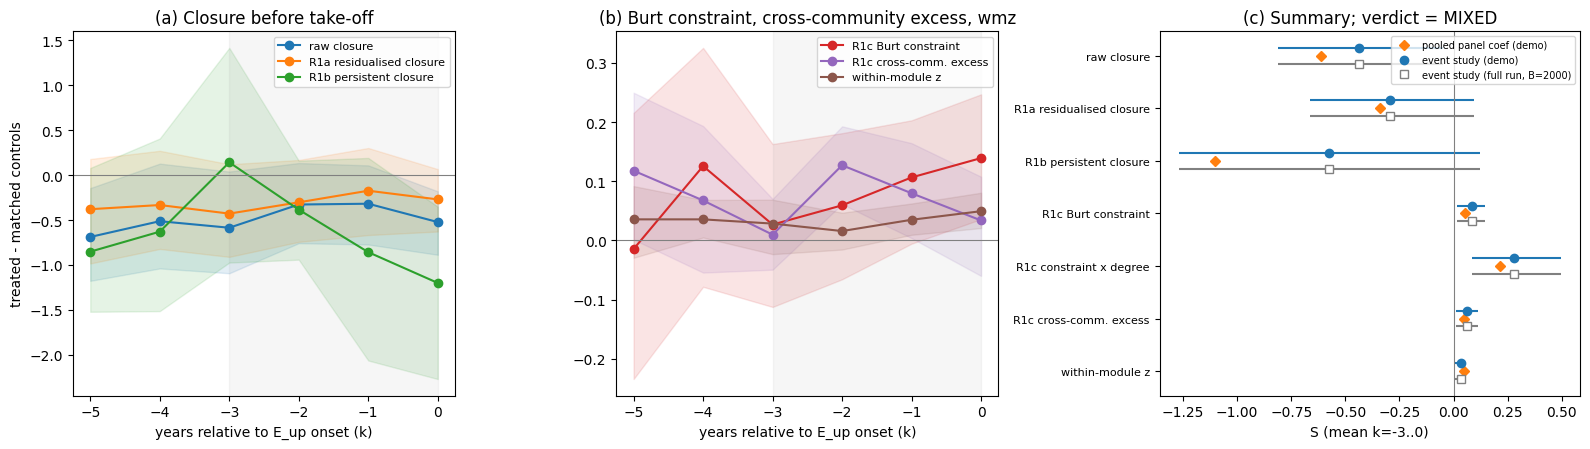

In [27]:
ks = S["es_rel_years"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw=dict(width_ratios=[1, 1, 1.1]))
# (a) closure family: event-study paths treated - matched controls, with bootstrap CI per k
ax = axes[0]
for c, col in (("closure", "#1f77b4"), ("closure_resT", "#ff7f0e"), ("closure_persist", "#2ca02c")):
    r = primary["rows"][c]
    dk, ck = np.array(r["diff_k"], float), np.array(r["ci_k"], float)
    ax.plot(ks, dk, "o-", color=col, label=label[c])
    ax.fill_between(ks, ck[:, 0], ck[:, 1], color=col, alpha=0.12)
ax.axhline(0, color="grey", lw=0.8); ax.axvspan(-3, 0, color="grey", alpha=0.07)
ax.set_xlabel("years relative to E_up onset (k)"); ax.set_ylabel("treated - matched controls")
ax.set_title("(a) Closure before take-off"); ax.legend(fontsize=8)
# (b) brokerage family
ax = axes[1]
for c, col in (("constraint", "#d62728"), ("xc_excess", "#9467bd"), ("wmz", "#8c564b")):
    r = primary["rows"][c]
    dk, ck = np.array(r["diff_k"], float), np.array(r["ci_k"], float)
    ax.plot(ks, dk, "o-", color=col, label=label[c])
    ax.fill_between(ks, ck[:, 0], ck[:, 1], color=col, alpha=0.12)
ax.axhline(0, color="grey", lw=0.8); ax.axvspan(-3, 0, color="grey", alpha=0.07)
ax.set_xlabel("years relative to E_up onset (k)"); ax.set_title("(b) Burt constraint, cross-community excess, wmz")
ax.legend(fontsize=8)
# (c) forest: S over k=-3..0, demo vs full run, plus pooled panel coefficient
ax = axes[2]
yy = np.arange(len(show))[::-1]
for i, c in zip(yy, show):
    st = primary["rows"][c]["primary"]
    ax.errorbar(st["S"], i + 0.15, xerr=[[st["S"] - st["ci"][0]], [st["ci"][1] - st["S"]]], fmt="o", color="#1f77b4",
                label="event study (demo)" if c == show[0] else None)
    rf = ref["primary"][c]
    ax.errorbar(rf["S"], i - 0.15, xerr=[[rf["S"] - rf["ci"][0]], [rf["ci"][1] - rf["S"]]], fmt="s", color="grey",
                mfc="white", label="event study (full run, B=2000)" if c == show[0] else None)
    pp = primary["pooled_panel"][c]
    ax.plot(pp["coef"], i, "D", color="#ff7f0e", ms=5, label="pooled panel coef (demo)" if c == show[0] else None)
ax.axvline(0, color="grey", lw=0.8)
ax.set_yticks(yy); ax.set_yticklabels([label[c] for c in show], fontsize=8)
ax.set_xlabel("S (mean k=-3..0)"); ax.set_title(f"(c) Summary; verdict = {v['verdict']}"); ax.legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

**Reading.** Before take-off, raw closure is lower in the treated concepts than in their matched never-emerging controls, and about two-thirds of that gap survives the turnover residualisation (R1a). The gap is therefore not just churn (**not TURNOVER**). But Burt constraint and the constraint × degree product are *higher* for the treated concepts, which is the opposite sign to brokerage, so the result is **not BROKERAGE** either. The mechanical verdict is **MIXED**. The picture is a cross-community, sparsely closed top-20 neighbourhood inside a more redundant wider ego network. With 26 matched onsets the primary cell is flagged `underpowered`. Adding the openness features does not improve prediction of E_up (ΔAUC ≈ 0).